In [2]:
pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from collections import Counter
from wordcloud import WordCloud


In [2]:
da = pd.read_excel("Data_Analytics_Empirical_Studies_SCR.xlsx")
bc = pd.read_excel("Blockchain and SCR.xlsx")


In [7]:
da["Year"] = da["Author(s), Year"].str.extract(r"(\d{4})")
bc["Year"] = bc["Author(s), Year"].str.extract(r"(\d{4})")

da = da.dropna(subset=["Year"])
bc = bc.dropna(subset=["Year"])

da["Year"] = da["Year"].astype(int)
bc["Year"] = bc["Year"].astype(int)


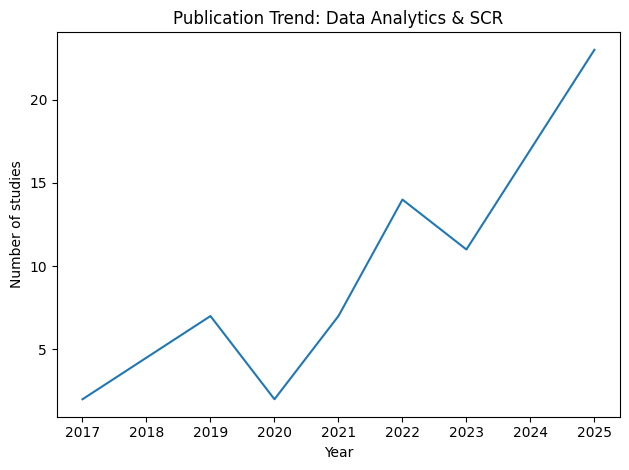

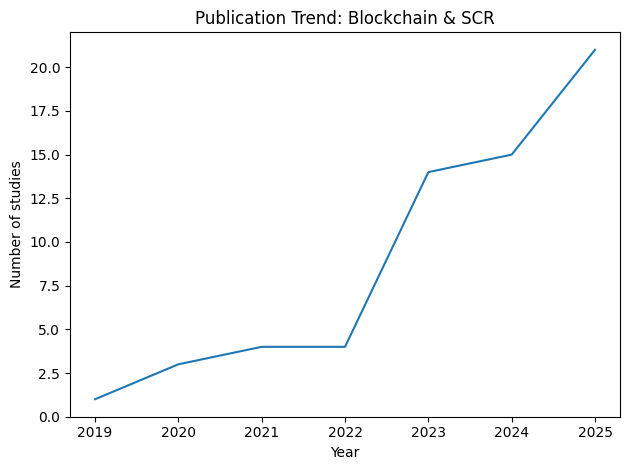

In [8]:
plt.figure()
da["Year"].value_counts().sort_index().plot()
plt.xlabel("Year"); plt.ylabel("Number of studies")
plt.title("Publication Trend: Data Analytics & SCR")
plt.tight_layout()
#plt.savefig("Figure1_DA_Publication_Trend.png", dpi=200)
plt.show()

plt.figure()
bc["Year"].value_counts().sort_index().plot()
plt.xlabel("Year"); plt.ylabel("Number of studies")
plt.title("Publication Trend: Blockchain & SCR")
plt.tight_layout()
#plt.savefig("Figure2_Blockchain_Publication_Trend.png", dpi=200)
plt.show()


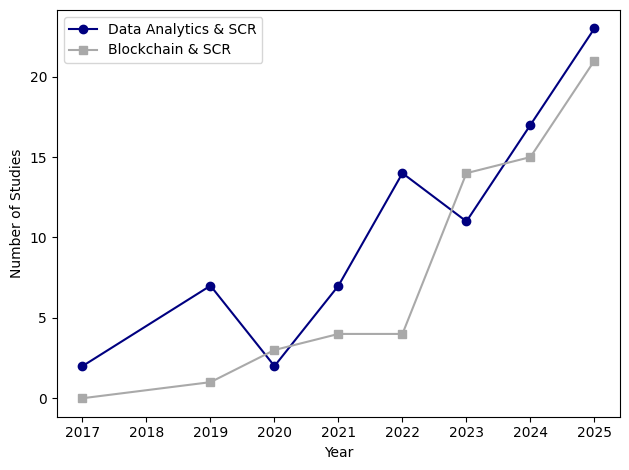

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
da = pd.read_excel("Data_Analytics_Empirical_Studies_SCR.xlsx")
bc = pd.read_excel("Blockchain and SCR.xlsx")

# Extract year
da["Year"] = da["Author(s), Year"].str.extract(r"(\d{4})")
bc["Year"] = bc["Author(s), Year"].str.extract(r"(\d{4})")

# Clean data
da = da.dropna(subset=["Year"])
bc = bc.dropna(subset=["Year"])

da["Year"] = da["Year"].astype(int)
bc["Year"] = bc["Year"].astype(int)

# Count publications per year
da_counts = da["Year"].value_counts().sort_index()
bc_counts = bc["Year"].value_counts().sort_index()

# Combine years to ensure same x-axis
all_years = sorted(set(da_counts.index).union(set(bc_counts.index)))

da_counts = da_counts.reindex(all_years, fill_value=0)
bc_counts = bc_counts.reindex(all_years, fill_value=0)

# Plot single graph with two lines
plt.figure()

plt.plot(all_years, da_counts, marker='o', color='Navy', label='Data Analytics & SCR')
plt.plot(all_years, bc_counts, marker='s', color='darkgray', label='Blockchain & SCR')

plt.xlabel("Year")
plt.ylabel("Number of Studies")
#plt.title("Publication Trend: Data Analytics vs Blockchain in SCR")
plt.legend()

plt.tight_layout()
plt.savefig("Figure_Publication_Trend_Combined.jpg", dpi=300)
plt.show()


In [5]:
def simplify_method(x):
    x = str(x).lower()
    if "survey" in x or "sem" in x: return "Survey / SEM"
    if "case" in x or "interview" in x: return "Case / Interview"
    if "mixed" in x: return "Mixed methods"
    if "archival" in x or "secondary" in x: return "Archival / Secondary"
    return "Other"

da["Method_Simple"] = da["Methodology"].apply(simplify_method)
bc["Method_Simple"] = bc["Methodology"].apply(simplify_method)


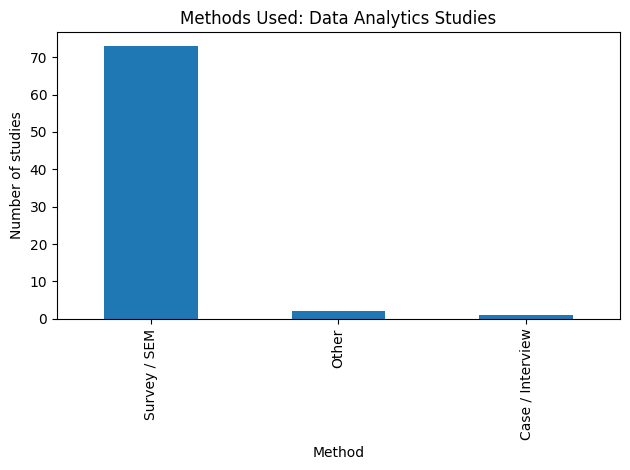

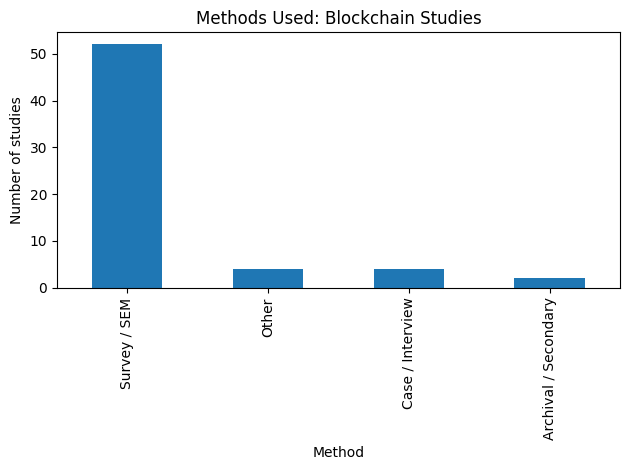

In [7]:
plt.figure()
da["Method_Simple"].value_counts().plot(kind="bar")
plt.xlabel("Method"); plt.ylabel("Number of studies")
plt.title("Methods Used: Data Analytics Studies")
plt.tight_layout()
plt.savefig("Figure3_DA_Methods.png", dpi=200)
plt.show()

plt.figure()
bc["Method_Simple"].value_counts().plot(kind="bar")
plt.xlabel("Method"); plt.ylabel("Number of studies")
plt.title("Methods Used: Blockchain Studies")
plt.tight_layout()
plt.savefig("Figure4_Blockchain_Methods.png", dpi=200)
plt.show()


In [12]:
keywords = [
    ("visibility", ["visibility"]),
    ("transparency", ["transparency"]),
    ("agility", ["agility"]),
    ("flexibility", ["flexibility"]),
    ("robustness", ["robustness"]),
    ("responsiveness", ["responsiveness", "response"]),
    ("recovery", ["recovery"]),
    ("adaptability", ["adaptability", "adaptive"]),
    ("collaboration", ["collaboration", "coordination"]),
    ("trust", ["trust"]),
]

def count_keyword(df, col, terms):
    s = df[col].fillna("").astype(str).str.lower()
    return sum(any(t in txt for t in terms) for txt in s)

da_counts = {name: count_keyword(da, "Resilience Dimensions", terms) for name, terms in keywords}
bc_counts = {name: count_keyword(bc, "Resilience Dimensions", terms) for name, terms in keywords}


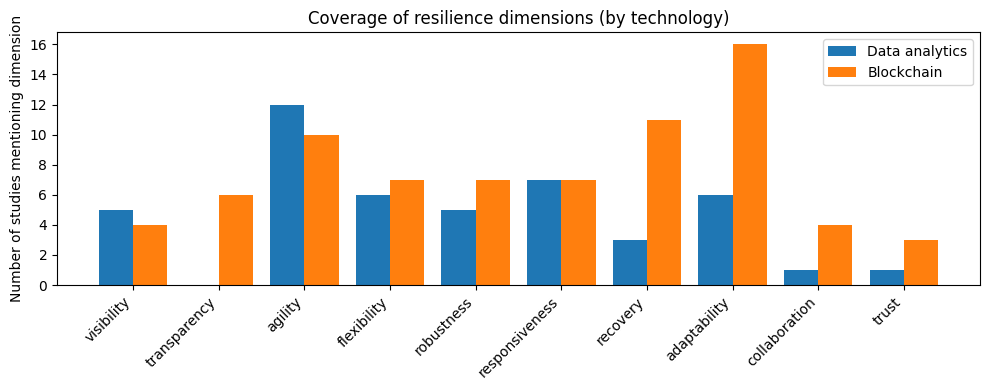

In [13]:
dims = [k[0] for k in keywords]
x = np.arange(len(dims))
w = 0.4

plt.figure(figsize=(10,4))
plt.bar(x-w/2, [da_counts[d] for d in dims], w, label="Data analytics")
plt.bar(x+w/2, [bc_counts[d] for d in dims], w, label="Blockchain")
plt.xticks(x, dims, rotation=45, ha="right")
plt.ylabel("Number of studies mentioning dimension")
plt.title("Coverage of resilience dimensions (by technology)")
plt.legend()
plt.tight_layout()
#plt.savefig("Figure5_Dimension_Coverage_Comparison.png", dpi=200)
plt.show()


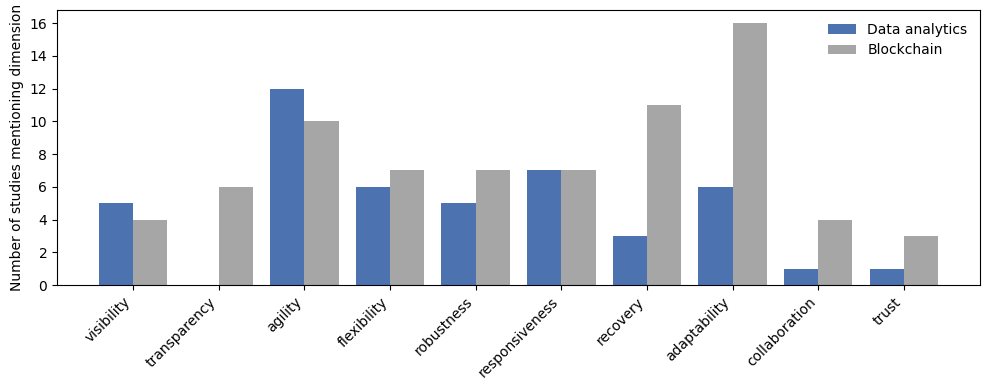

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dims = [k[0] for k in keywords]
x = np.arange(len(dims))
w = 0.4

plt.figure(figsize=(10,4))

# Professional muted colors
color_da = "#4C72B0"     # Deep academic blue
color_bc = "#A6A6A6"     # Muted burnt orange

plt.bar(x-w/2, [da_counts[d] for d in dims], w, 
        label="Data analytics", color=color_da)

plt.bar(x+w/2, [bc_counts[d] for d in dims], w, 
        label="Blockchain", color=color_bc)

plt.xticks(x, dims, rotation=45, ha="right", color="black")
plt.ylabel("Number of studies mentioning dimension", color="black")
# plt.title("Coverage of resilience dimensions (by technology)")

plt.legend(frameon=False,)  # Cleaner legend
# plt.grid(axis="y", linestyle="--", alpha=0.4)  # Light horizontal grid

plt.tight_layout()
#plt.savefig("Dimension_Coverage_Comparison.jpg", dpi=300)
plt.show()


In [20]:
def build_presence(df):
    s = df["Resilience Dimensions"].fillna("").astype(str).str.lower()
    pres = pd.DataFrame(index=df.index, columns=dims, data=False)
    for name, terms in keywords:
        pres[name] = s.apply(lambda x: any(t in x for t in terms))
    return pres

da_pres = build_presence(da)
bc_pres = build_presence(bc)


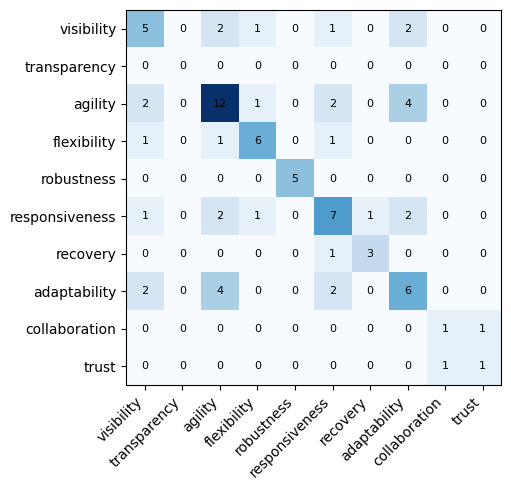

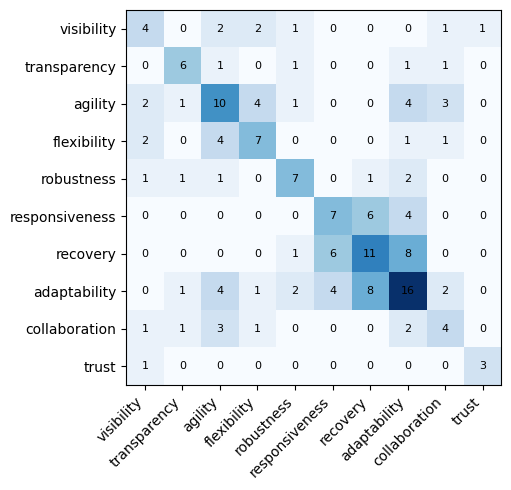

In [22]:
def cooccurrence(pres_df):
    m = pres_df.astype(int).to_numpy()
    return m.T @ m

def plot_heat(mat, title, file):
    plt.figure(figsize=(6,5))
    plt.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max())
    plt.xticks(np.arange(len(dims)), dims, rotation=45, ha="right")
    plt.yticks(np.arange(len(dims)), dims)
    # plt.title(title)
    for i in range(len(dims)):
        for j in range(len(dims)):
            plt.text(j, i, int(mat[i,j]), ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(file, dpi=300)
    plt.show()

plot_heat(cooccurrence(da_pres), "Co-occurrence of resilience dimensions (Data analytics)", "Figure6a_DA_Cooccurrence.jpg")
plot_heat(cooccurrence(bc_pres), "Co-occurrence of resilience dimensions (Blockchain)", "Figure6b_Blockchain_Cooccurrence.jpg")


In [23]:
text_cols = ["Resilience Dimensions","Inputs","Mediators/Moderators","Outputs","Key Findings"]

def build_corpus(df):
    parts = []
    for c in text_cols:
        parts.append(df[c].fillna("").astype(str))
    corpus = " ".join(pd.concat(parts).tolist()).lower()
    corpus = re.sub(r"[^a-z\s]", " ", corpus)
    corpus = re.sub(r"\s+", " ", corpus).strip()
    return corpus

da_corpus = build_corpus(da)
bc_corpus = build_corpus(bc)


In [24]:
stop = set("""
the a an and or of to in for with on by from at as is are was were be been being
supply chain resilience scr study studies empirical paper model results findings
data analytics blockchain technology technologies
""".split())

def term_freq(corpus):
    words = [w for w in corpus.split() if len(w)>=3 and w not in stop]
    return Counter(words)

da_freq = term_freq(da_corpus)
bc_freq = term_freq(bc_corpus)


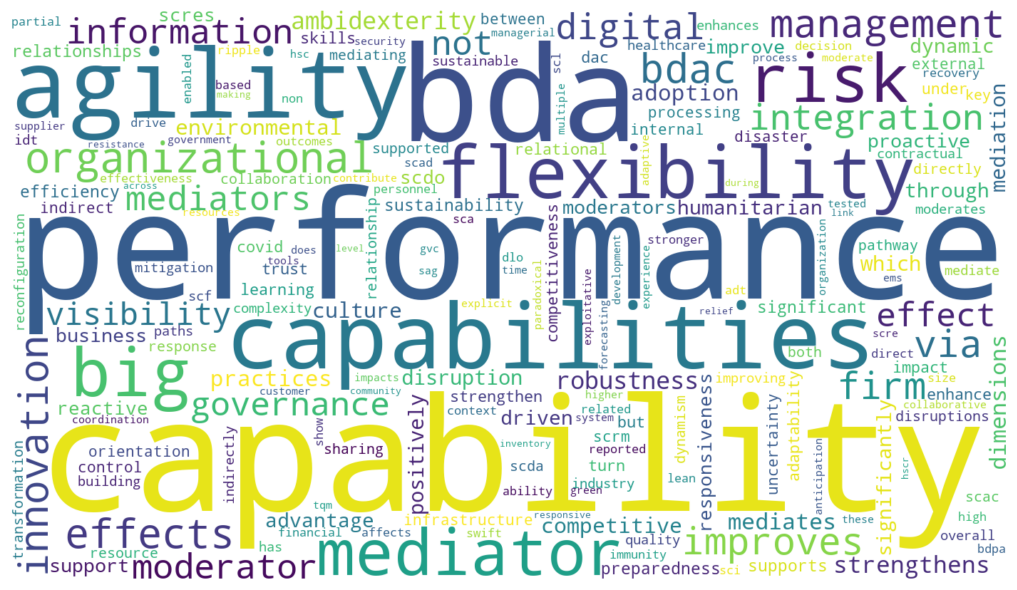

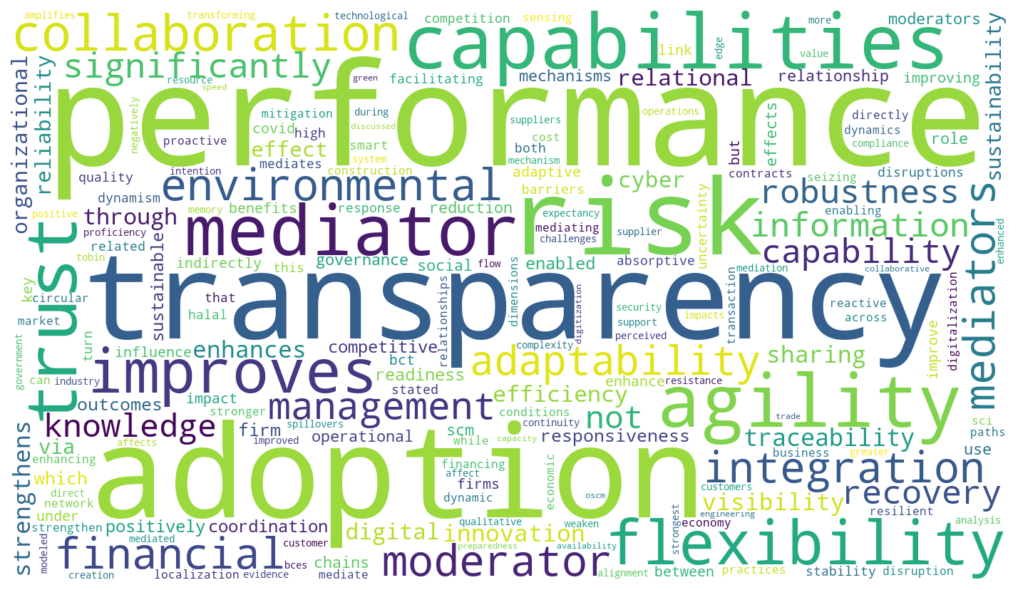

In [37]:
wc_da = WordCloud(width=1400, height=800, background_color="white").generate_from_frequencies(da_freq)
wc_bc = WordCloud(width=1400, height=800, background_color="white").generate_from_frequencies(bc_freq)

plt.figure(figsize=(12,6))
plt.imshow(wc_da, interpolation="bilinear")
plt.axis("off")
#plt.title("Word cloud: Data Analytics–SCR empirical studies")
plt.tight_layout()
#plt.savefig("Figure7_DA_WordCloud.png", dpi=200)
plt.show()

plt.figure(figsize=(12,6))
plt.imshow(wc_bc, interpolation="bilinear")
plt.axis("off")
#plt.title("Word cloud: Blockchain–SCR empirical studies")
plt.tight_layout()
# plt.savefig("Figure8_Blockchain_WordCloud.png", dpi=200)
plt.show()


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

da = pd.read_excel("Data_Analytics_Empirical_Studies_SCR.xlsx")
bc = pd.read_excel("Blockchain and SCR.xlsx")


In [29]:
def count_presence(df, cols, terms):
    series = pd.Series([""] * len(df))
    for c in cols:
        if c in df.columns:
            series = series + " " + df[c].fillna("").astype(str)
    series = series.str.lower()
    return int(series.apply(lambda x: any(t in x for t in terms)).sum())

def build_counts(df, cols, keyword_map):
    return {k: count_presence(df, cols, v) for k, v in keyword_map.items()}


In [30]:
mechanisms = {
    "Visibility": ["visibility", "real-time", "monitor", "tracking", "trace"],
    "Transparency": ["transparency", "audit", "immutable", "ledger"],
    "Traceability": ["traceability", "provenance", "track and trace"],
    "Trust": ["trust", "credibility", "reliability"],
    "Collaboration": ["collaboration", "coordination", "information sharing", "data sharing", "partner"],
    "Governance": ["governance", "contract", "smart contract", "compliance", "regulation"],
    "Sensing/Prediction": ["predict", "forecast", "early warning", "sensing", "prediction"],
    "Decision support": ["decision", "optimization", "prescriptive", "scenario", "simulation"],
    "Flexibility/Agility": ["agility", "flexibility", "responsiveness", "reconfigur"],
    "Risk mitigation": ["risk", "mitigation", "risk management", "uncertainty"],
}

mech_cols = ["Inputs", "Mediators/Moderators", "Key Findings", "Resilience Dimensions", "Outputs"]


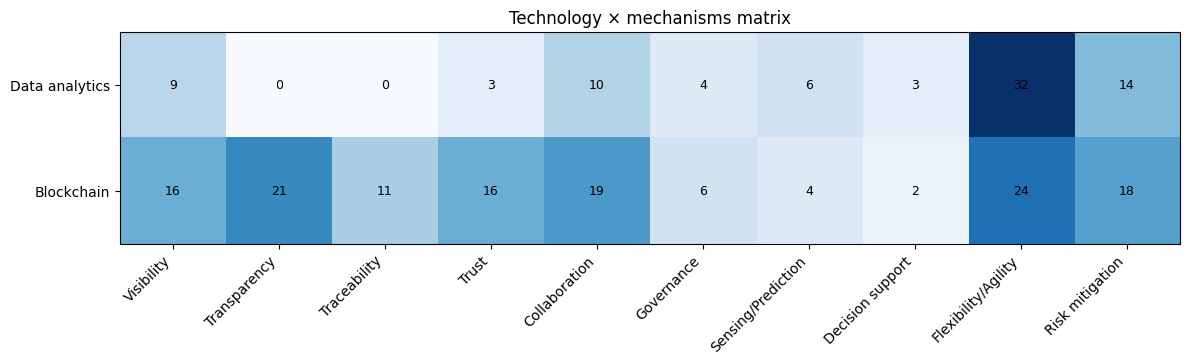

In [31]:
da_mech = build_counts(da, mech_cols, mechanisms)
bc_mech = build_counts(bc, mech_cols, mechanisms)

mech_names = list(mechanisms.keys())
matrix_mech = np.array([
    [da_mech[m] for m in mech_names],
    [bc_mech[m] for m in mech_names]
])

plt.figure(figsize=(12,3.5))
plt.imshow(matrix_mech, cmap="Blues")
plt.xticks(np.arange(len(mech_names)), mech_names, rotation=45, ha="right")
plt.yticks([0,1], ["Data analytics", "Blockchain"])
plt.title("Technology × mechanisms matrix")

for i in range(matrix_mech.shape[0]):
    for j in range(matrix_mech.shape[1]):
        plt.text(j, i, int(matrix_mech[i,j]), ha="center", va="center", fontsize=9)

plt.tight_layout()
#plt.savefig("Figure9_Tech_by_Mechanisms_Matrix.png", dpi=200)
plt.show()


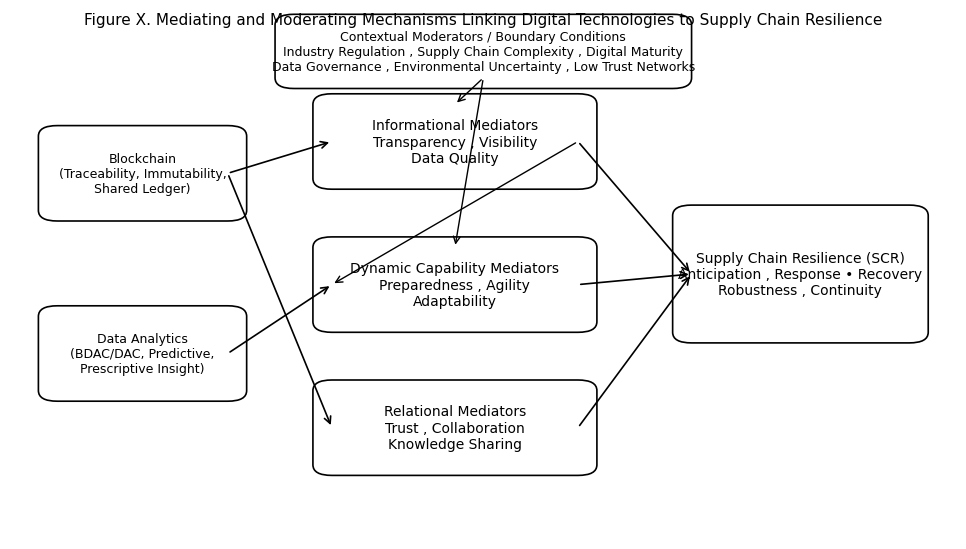

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, xy, w, h, text, fontsize=10):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)
    return (x, y, w, h)

def center_right(b):  # point on right edge
    x, y, w, h = b
    return (x + w, y + h/2)

def center_left(b):   # point on left edge
    x, y, w, h = b
    return (x, y + h/2)

def center_top(b):    # point on top edge
    x, y, w, h = b
    return (x + w/2, y + h)

def center_bottom(b): # point on bottom edge
    x, y, w, h = b
    return (x + w/2, y)

def add_arrow(ax, p1, p2, lw=1.2):
    arr = FancyArrowPatch(
        p1, p2,
        arrowstyle="->",
        mutation_scale=12,
        linewidth=lw,
        color="black",
        connectionstyle="arc3,rad=0.0"
    )
    ax.add_patch(arr)

# --- Figure canvas ---
fig = plt.figure(figsize=(10, 5.6))
ax = plt.gca()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# --- Boxes (positions tuned for clarity) ---
blockchain = add_box(
    ax, (0.05, 0.62), 0.18, 0.14,
    "Blockchain\n(Traceability, Immutability,\nShared Ledger)", fontsize=9
)

analytics = add_box(
    ax, (0.05, 0.28), 0.18, 0.14,
    "Data Analytics\n(BDAC/DAC, Predictive,\nPrescriptive Insight)", fontsize=9
)

info_med = add_box(
    ax, (0.34, 0.68), 0.26, 0.14,
    "Informational Mediators\nTransparency , Visibility\nData Quality", fontsize=10
)

dyn_med = add_box(
    ax, (0.34, 0.41), 0.26, 0.14,
    "Dynamic Capability Mediators\nPreparedness , Agility\nAdaptability", fontsize=10
)

rel_med = add_box(
    ax, (0.34, 0.14), 0.26, 0.14,
    "Relational Mediators\nTrust , Collaboration\nKnowledge Sharing", fontsize=10
)

scr = add_box(
    ax, (0.72, 0.39), 0.23, 0.22,
    "Supply Chain Resilience (SCR)\nAnticipation , Response • Recovery\nRobustness , Continuity", fontsize=10
)

mods = add_box(
    ax, (0.30, 0.87), 0.40, 0.10,
    "Contextual Moderators / Boundary Conditions\nIndustry Regulation , Supply Chain Complexity , Digital Maturity\nData Governance , Environmental Uncertainty , Low Trust Networks",
    fontsize=9
)

# --- Arrows (Technology -> Mediators) ---
add_arrow(ax, center_right(blockchain), center_left(info_med))
add_arrow(ax, center_right(blockchain), center_left(rel_med))
add_arrow(ax, center_right(analytics), center_left(dyn_med))

# Optional cross-links (synergy): blockchain supports analytics via trusted data
add_arrow(ax, center_right(info_med), center_left(dyn_med), lw=1.0)

# --- Arrows (Mediators -> SCR) ---
add_arrow(ax, center_right(info_med), center_left(scr))
add_arrow(ax, center_right(dyn_med), center_left(scr))
add_arrow(ax, center_right(rel_med), center_left(scr))

# --- Moderator arrows (moderators affect relationships) ---
# Use downward arrows pointing to mediator layer
add_arrow(ax, center_bottom(mods), center_top(info_med), lw=1.0)
add_arrow(ax, center_bottom(mods), center_top(dyn_med), lw=1.0)

# --- Title ---
ax.text(0.5, 0.995,
        "Figure X. Mediating and Moderating Mechanisms Linking Digital Technologies to Supply Chain Resilience",
        ha="center", va="top", fontsize=11)

# --- Save outputs (high resolution) ---
plt.tight_layout()
plt.savefig("moderators_mediators_SCR.png", dpi=300, bbox_inches="tight")
plt.savefig("moderators_mediators_SCR.svg", bbox_inches="tight")
plt.show()


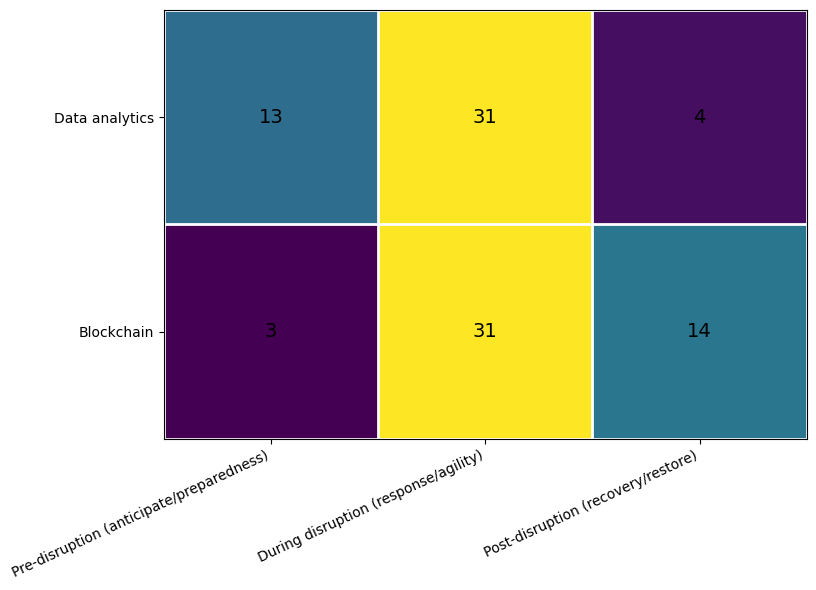

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Data (matrix)
data = np.array([
    [13, 31, 4],   # Data analytics
    [3, 31, 14]    # Blockchain
])

row_labels = ["Data analytics", "Blockchain"]
col_labels = [
    "Pre-disruption (anticipate/preparedness)",
    "During disruption (response/agility)",
    "Post-disruption (recovery/restore)"
]

# Create plot
fig, ax = plt.subplots(figsize=(9, 6))

# Show heatmap (equal-sized cells)
im = ax.imshow(data, aspect='equal')

# Set labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))

ax.set_xticklabels(col_labels, rotation=25, ha="right")
ax.set_yticklabels(row_labels)

# Add numbers inside cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, data[i, j],
                ha="center", va="center", fontsize=14, color="black")

# Optional: custom colors similar to your image
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#2F5597", "#A6A6A6", "#D9D9D9"])
im.set_cmap("viridis")  # or use cmap above

# Remove grid lines (optional)
ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

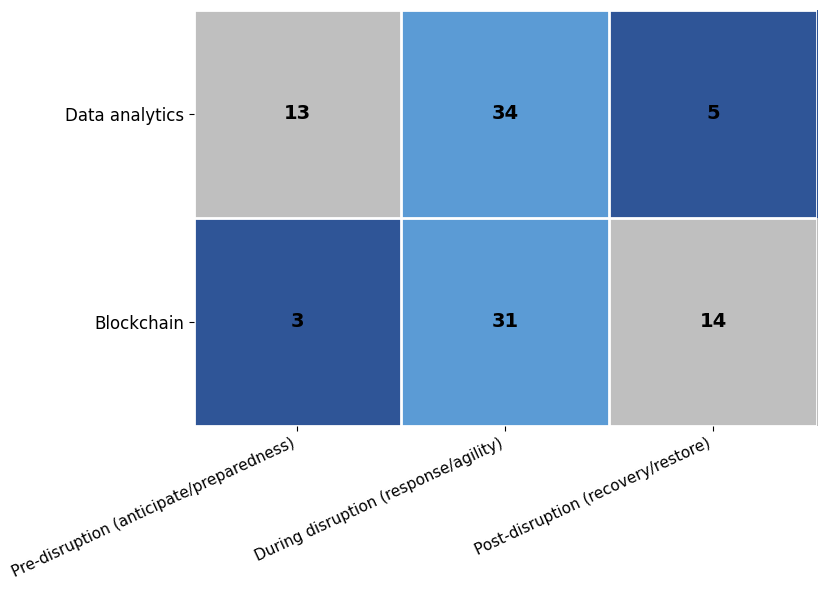

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Data
data = np.array([
    [13, 34, 5],   # Data analytics
    [3, 31, 14]    # Blockchain
])

row_labels = ["Data analytics", "Blockchain"]
col_labels = [
    "Pre-disruption (anticipate/preparedness)",
    "During disruption (response/agility)",
    "Post-disruption (recovery/restore)"
]

# Professional color palette (Blue–Orange–Gray)
colors = ["#2F5597", "#5B9BD5", "#BFBFBF"]  # Blue, Orange, Gray
cmap = ListedColormap(colors)

# Normalize values into 3 categories (low, medium, high)
# This ensures distinct colors instead of gradient
norm_data = np.zeros_like(data)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if data[i, j] <= 10:
            norm_data[i, j] = 0   # Blue (low)
        elif data[i, j] <= 20:
            norm_data[i, j] = 2   # Gray (medium)
        else:
            norm_data[i, j] = 1   # Orange (high)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(norm_data, cmap=cmap, aspect='equal')

# Labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))

ax.set_xticklabels(col_labels, rotation=25, ha="right", fontsize=11)
ax.set_yticklabels(row_labels, fontsize=12)

# Add values inside cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, str(data[i, j]),
                ha="center", va="center",
                fontsize=14, fontweight="bold", color="black")

# Grid lines for matrix look
ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Remove spines for clean look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Save high-resolution figure (for paper)
plt.savefig("matrix_figure.png", dpi=300, bbox_inches='tight')

plt.show()

In [3]:
import yfinance as yf
import pandas as pd

# 1. Tickers and company names
ticker_names = {
    "NSRGY": "Nestlé",
    "DANOY": "Danone",
    "UL": "Unilever",
    "ABF.L": "Associated British Foods",
    "HEIA.AS": "Heineken",
    "CABGY": "Carlsberg",
    "YAR.OL": "Yara International",
    "SDF.DE": "K+S AG",
    "OCI.AS": "OCI NV",
    "BG": "Bunge",
    "ADM": "Archer Daniels Midland",
    "KER.WA": "Kernel Holding",
    "MHPC.L": "MHP",
    "AST.WA": "Astarta Holding",
    "IMC.WA": "IMC",
    "TSN": "Tyson Foods",
    "B4B.HM": "Metro AG",
    "AUG1L.VS": "AUGA Group",
    "AKO1L.VS": "Akola Group",
    "PZV1L.VS": "Pieno Žvaigždės",
    "ZMP1L.VS": "Žemaitijos Pienas",
    "KYGA.L": "Kerry Group",
    "NSIS-B.CO": "Novonesis",
    "ORK.OL": "Orkla",
    "SALM.OL": "SalMar",
    "MOWI.OL": "Mowi",
    "AD.AS": "Ahold Delhaize"
}

tickers = list(ticker_names.keys())

# 2. Download 6 years stock price data
data = yf.download(
    tickers,
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=True,
    threads=False
)["Close"]

# 3. Save wide format file
data.to_csv("agrifood_stock_prices_wide.csv")

# 4. Convert to long format
df_long = data.reset_index().melt(
    id_vars=["Date"],
    var_name="Ticker",
    value_name="Price"
)

# 5. Add company names
df_long["Company"] = df_long["Ticker"].map(ticker_names)

# 6. Remove empty price rows
df_long = df_long.dropna(subset=["Price"])

# 7. Sort data
df_long = df_long.sort_values(["Company", "Date"])

# 8. Calculate daily return
df_long["Return"] = df_long.groupby("Company")["Price"].pct_change()

# 9. Add disruption event columns
df_long["COVID_Period"] = df_long["Date"].between("2020-03-01", "2020-06-30").astype(int)
df_long["Ukraine_War_Period"] = df_long["Date"].between("2022-02-24", "2022-06-30").astype(int)

# 10. Save final research-ready dataset
df_long.to_csv("agrifood_stock_data_research_ready.csv", index=False)

print("Dataset created successfully!")
print(df_long.head())
print("Total rows:", len(df_long))
print("Companies included:", df_long["Company"].nunique())

[**********************78%************           ]  21 of 27 completed$B4B.HM: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546297200, endDate = 1735686000")
[*********************100%***********************]  27 of 27 completed

1 Failed download:
['B4B.HM']: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1546297200, endDate = 1735686000")


Dataset created successfully!
           Date    Ticker  Price     Company   Return  COVID_Period  \
7780 2019-01-01  AUG1L.VS  0.400  AUGA Group      NaN             0   
7781 2019-01-02  AUG1L.VS  0.398  AUGA Group -0.00500             0   
7782 2019-01-03  AUG1L.VS  0.398  AUGA Group  0.00000             0   
7783 2019-01-04  AUG1L.VS  0.394  AUGA Group -0.01005             0   
7784 2019-01-07  AUG1L.VS  0.394  AUGA Group  0.00000             0   

      Ukraine_War_Period  
7780                   0  
7781                   0  
7782                   0  
7783                   0  
7784                   0  
Total rows: 39350
Companies included: 26


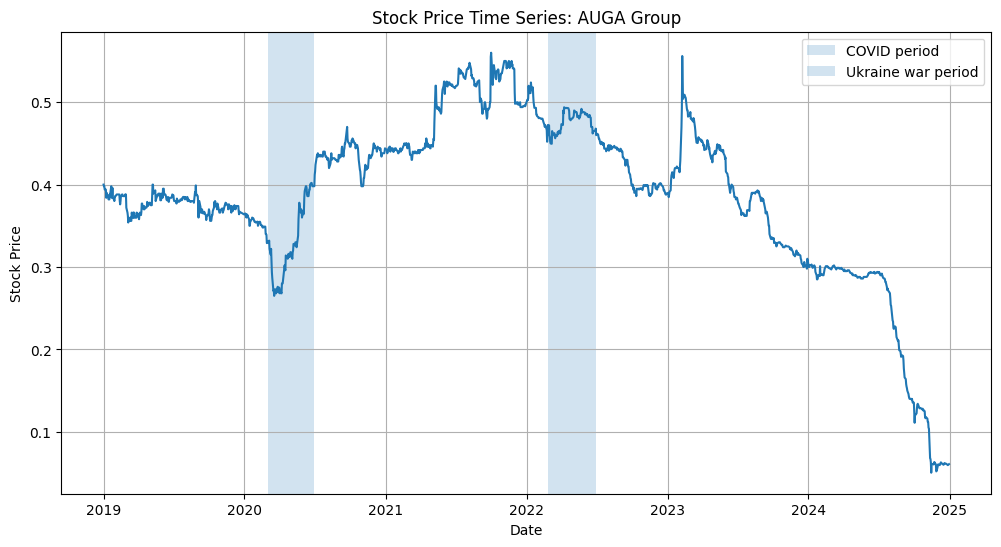

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your saved file
df = pd.read_csv("agrifood_stock_data_research_ready.csv")

# Convert Date column to proper date format
df["Date"] = pd.to_datetime(df["Date"])

# -------------------------------
# 1. Time-series graph: Stock price
# -------------------------------

company_name = "AUGA Group"   # change company name here

company_df = df[df["Company"] == company_name]

plt.figure(figsize=(12, 6))
plt.plot(company_df["Date"], company_df["Price"])

plt.axvspan(pd.to_datetime("2020-03-01"), pd.to_datetime("2020-06-30"), alpha=0.2, label="COVID period")
plt.axvspan(pd.to_datetime("2022-02-24"), pd.to_datetime("2022-06-30"), alpha=0.2, label="Ukraine war period")

plt.title(f"Stock Price Time Series: {company_name}")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

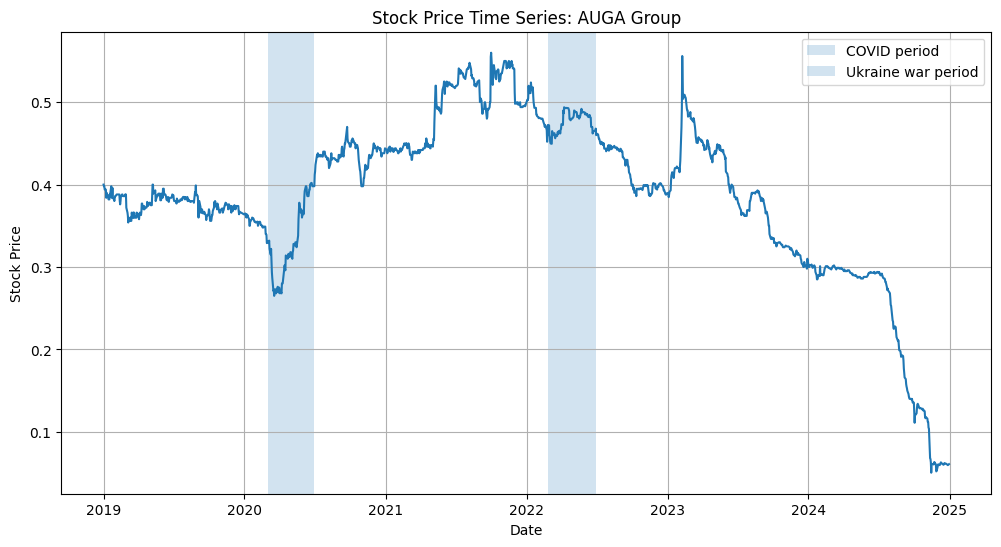

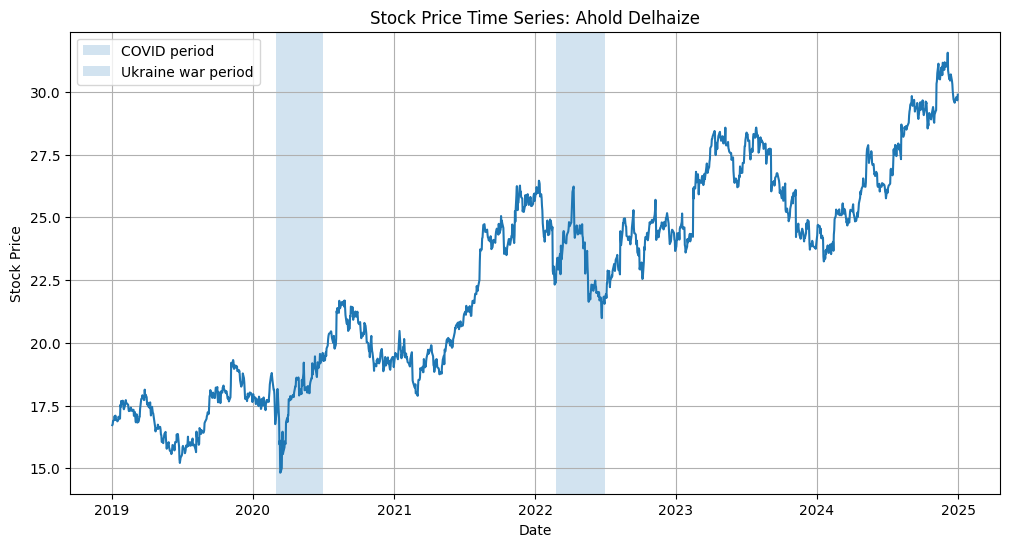

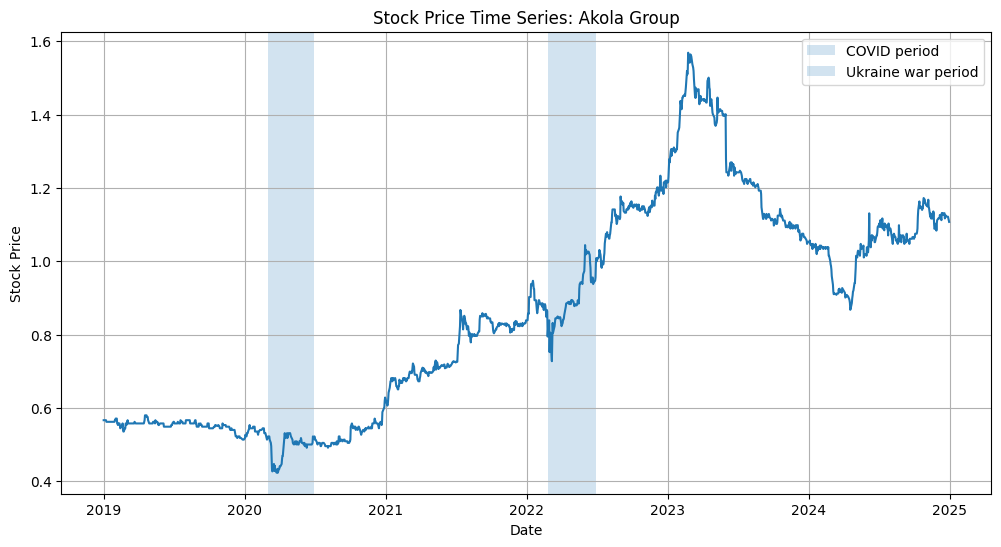

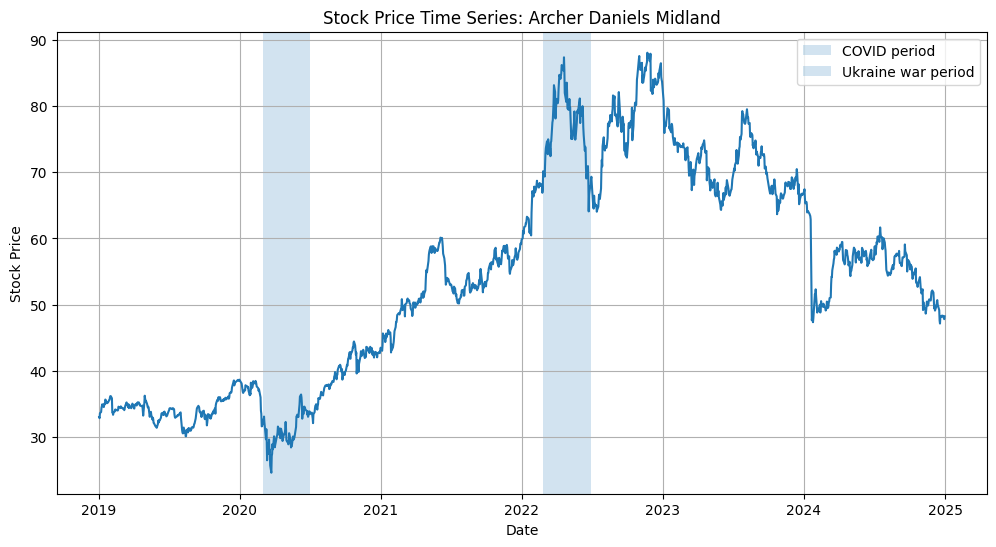

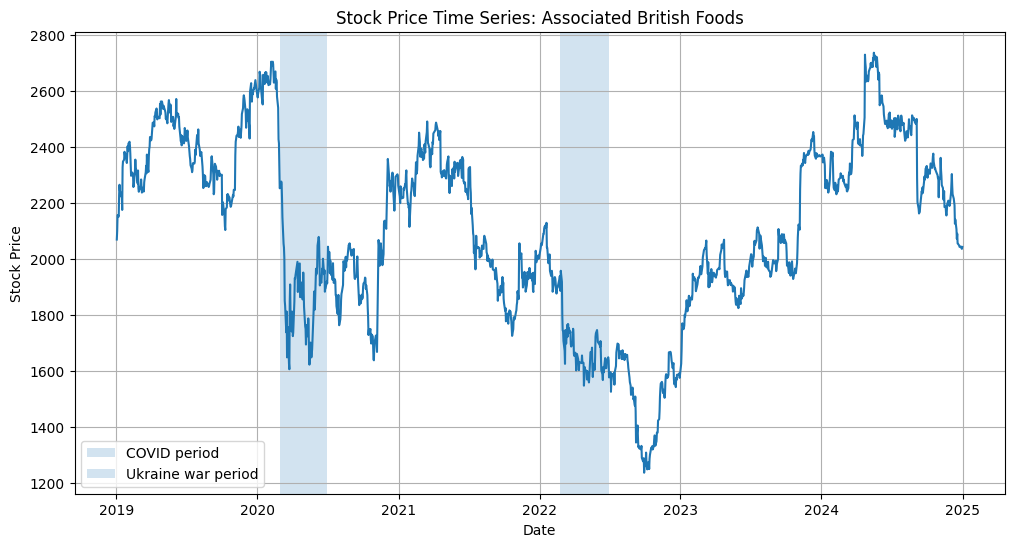

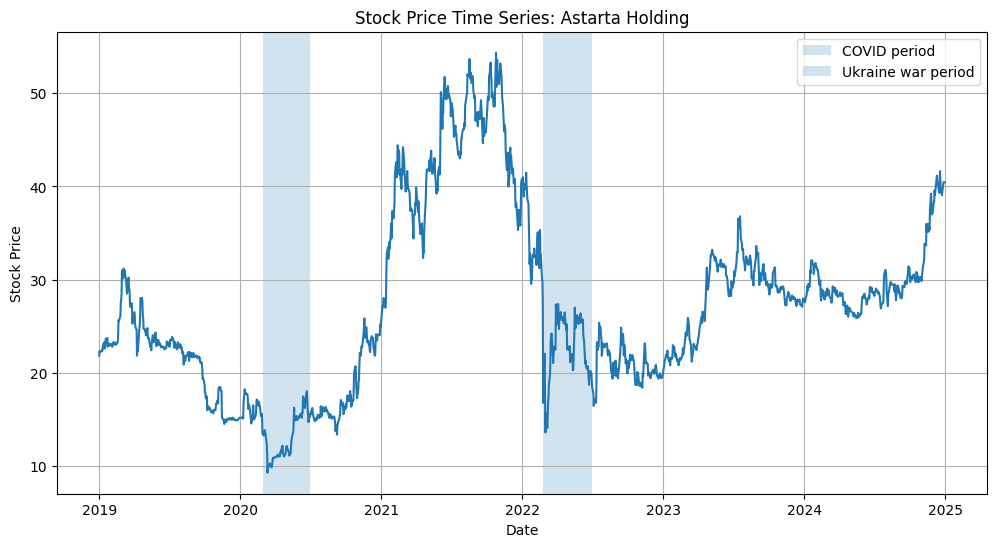

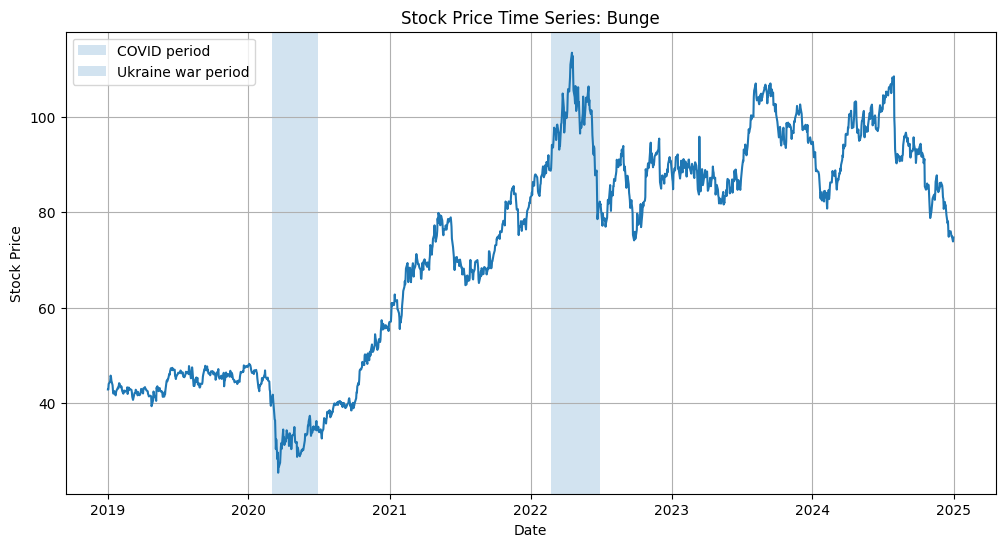

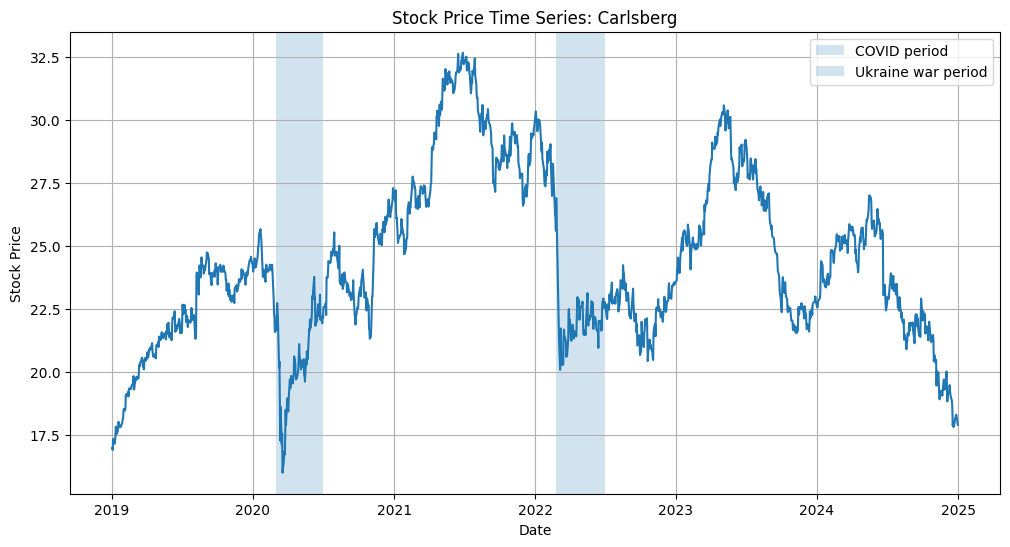

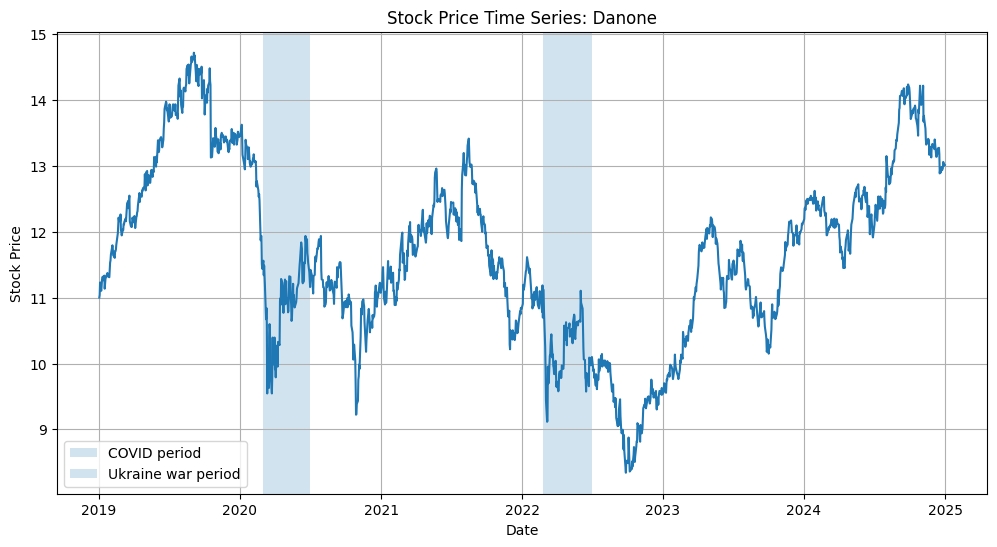

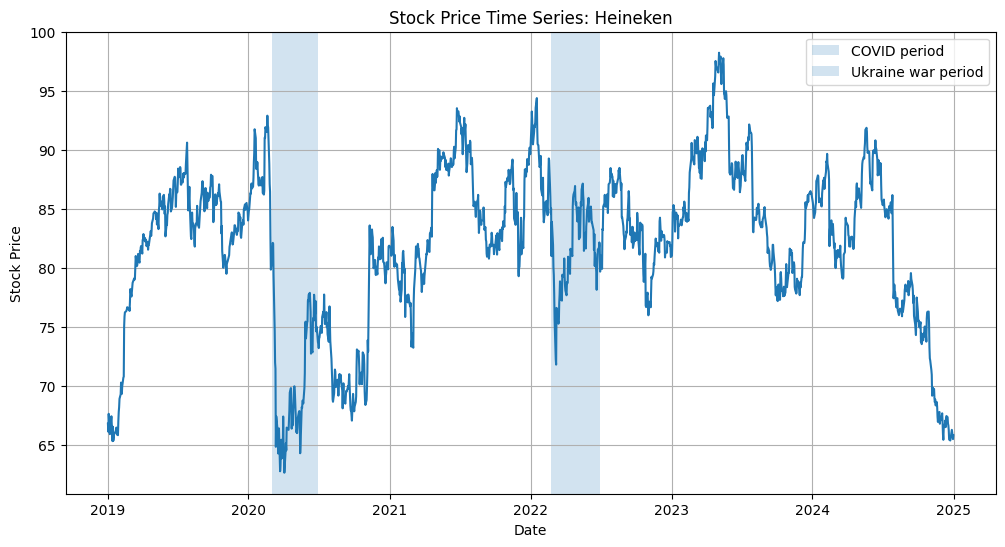

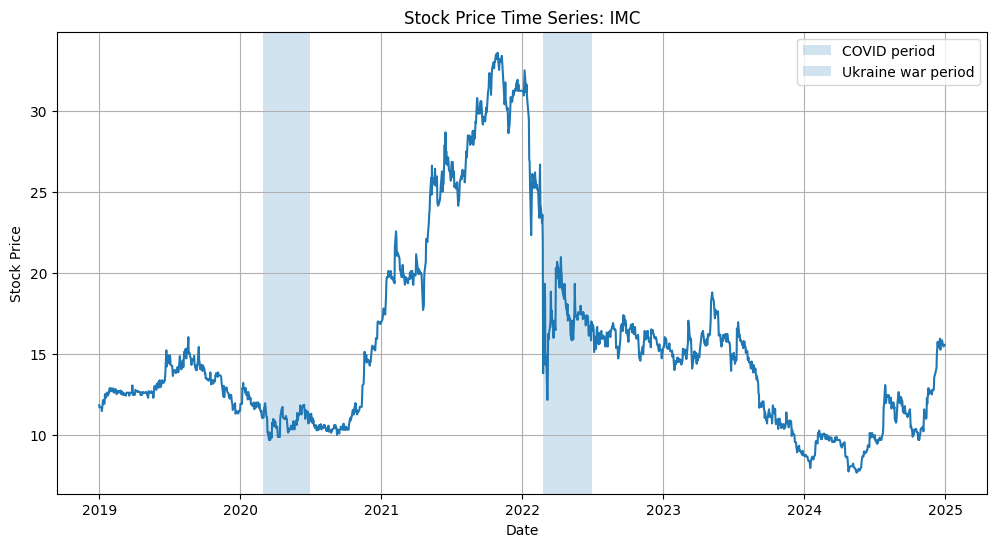

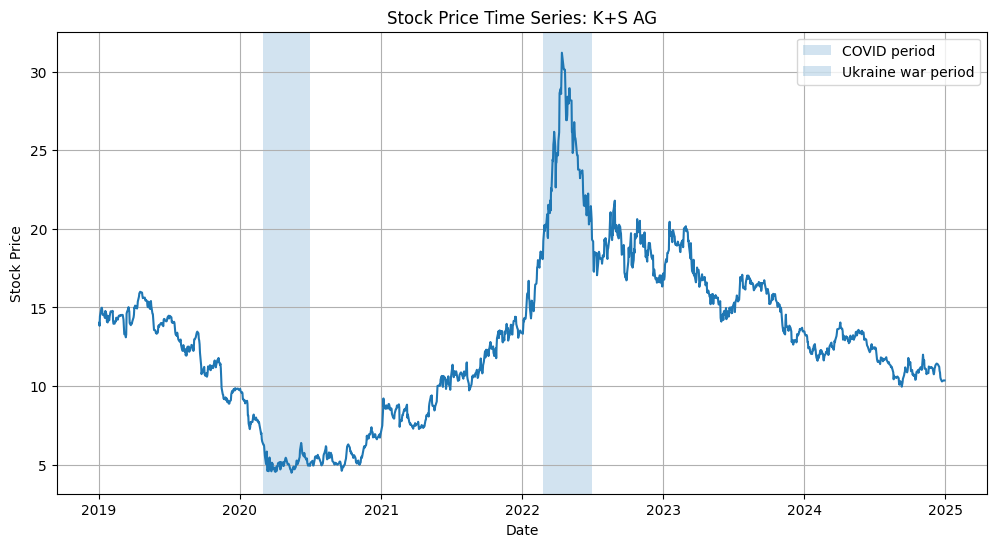

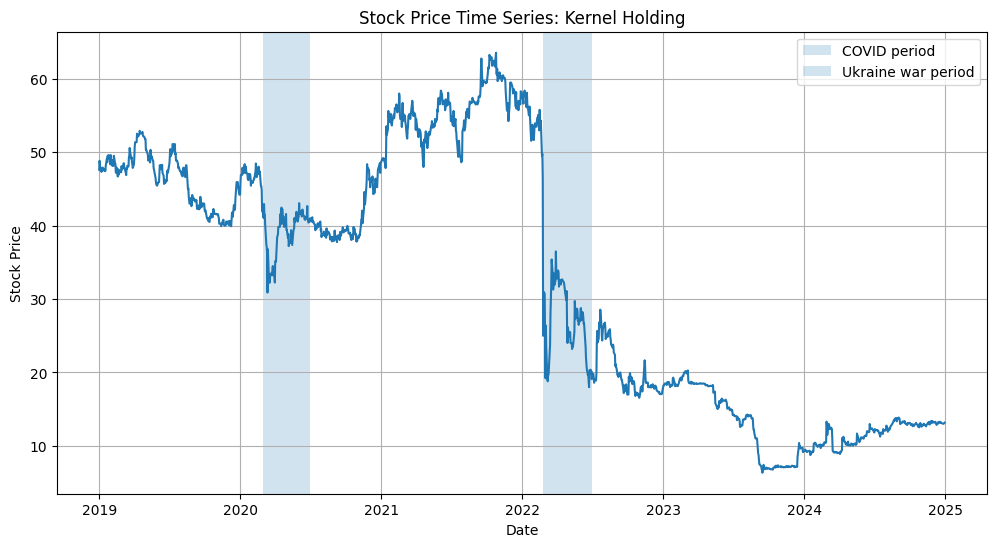

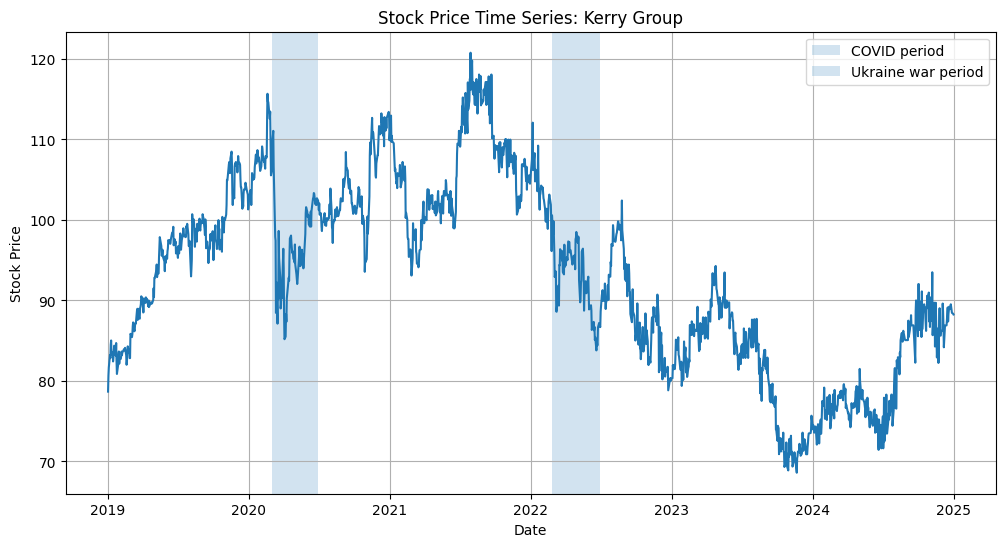

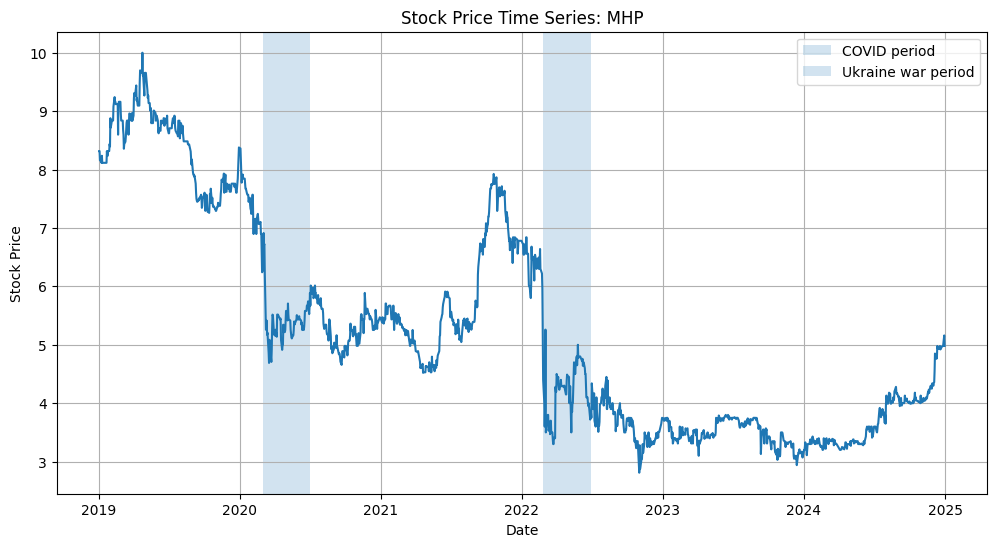

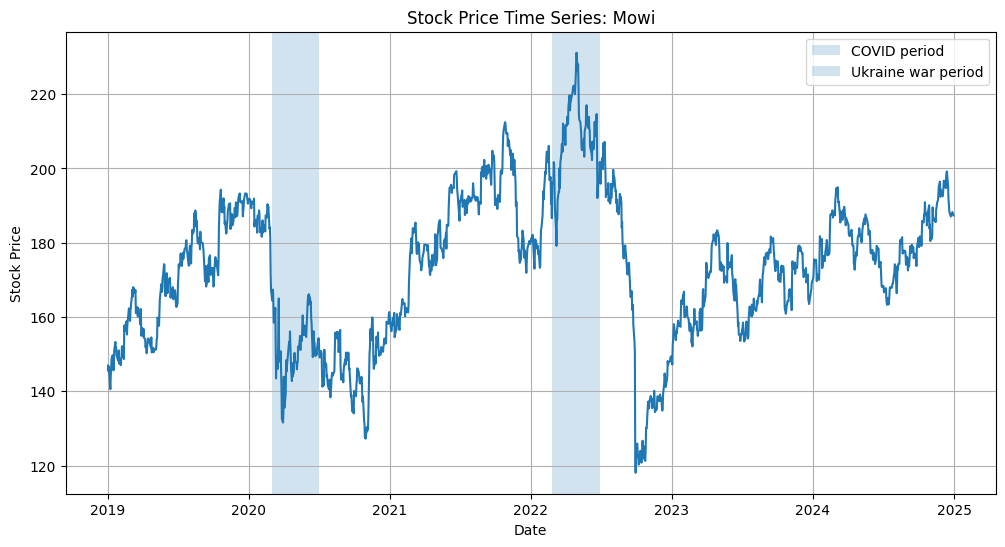

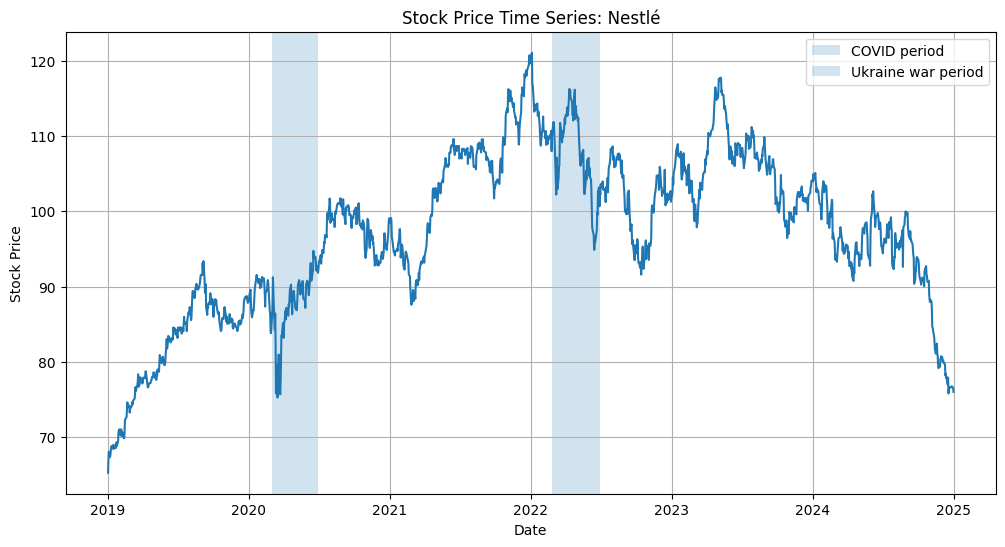

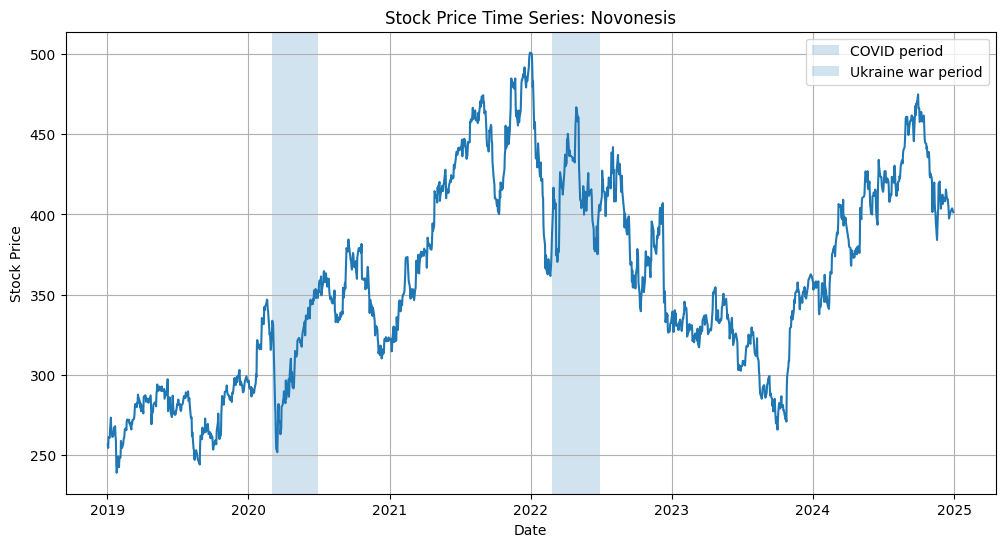

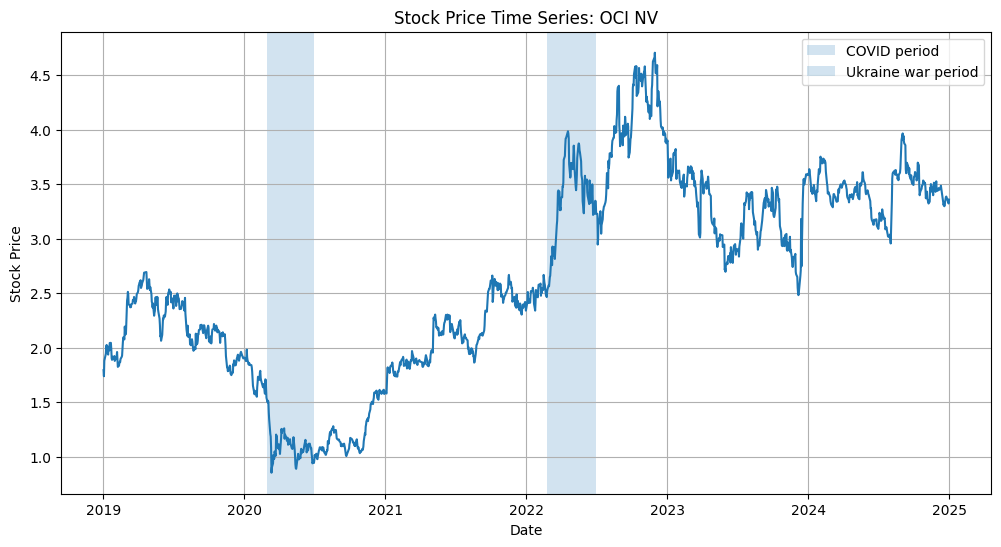

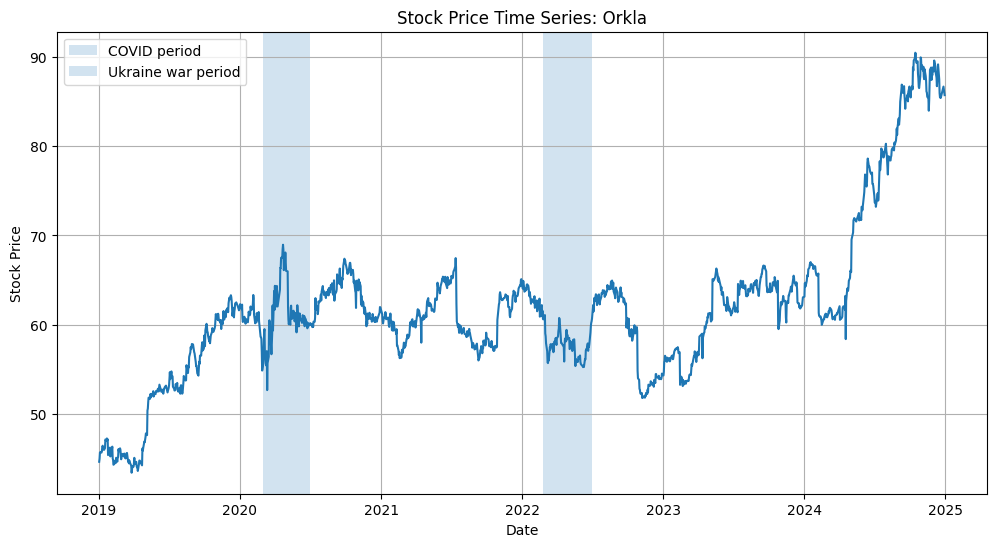

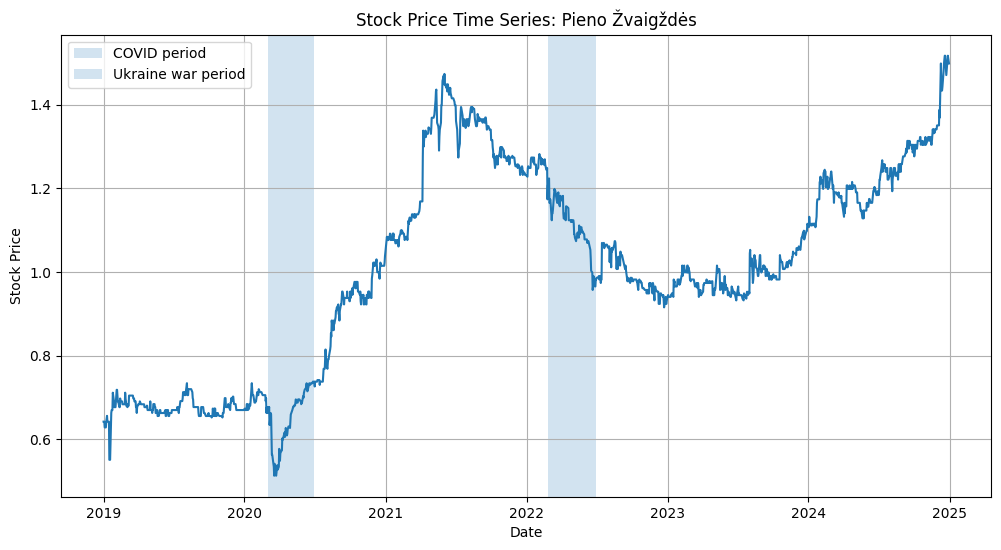

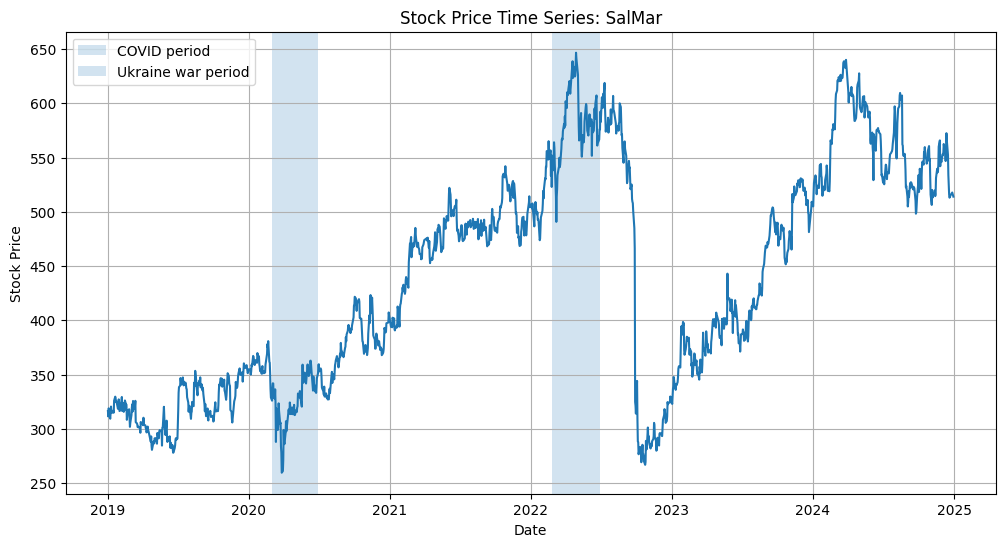

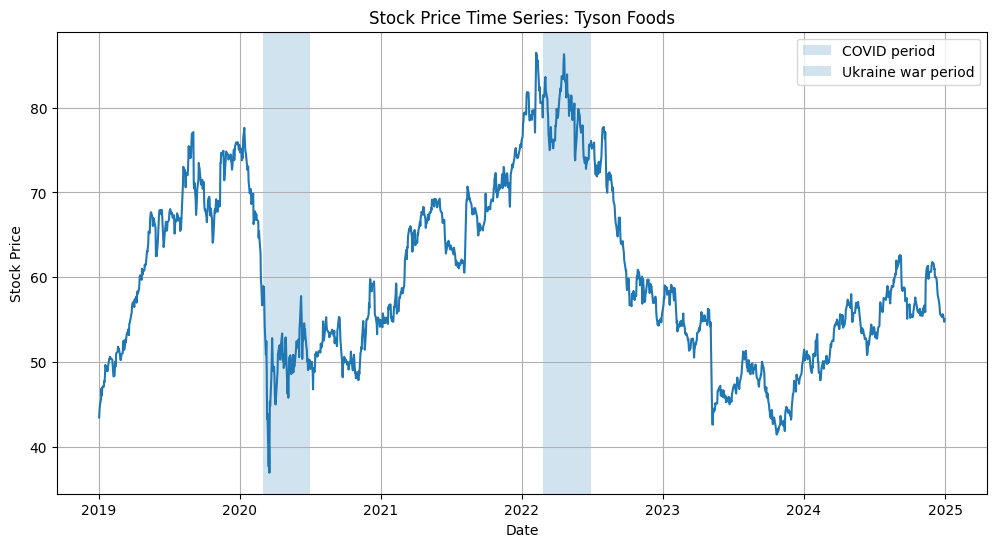

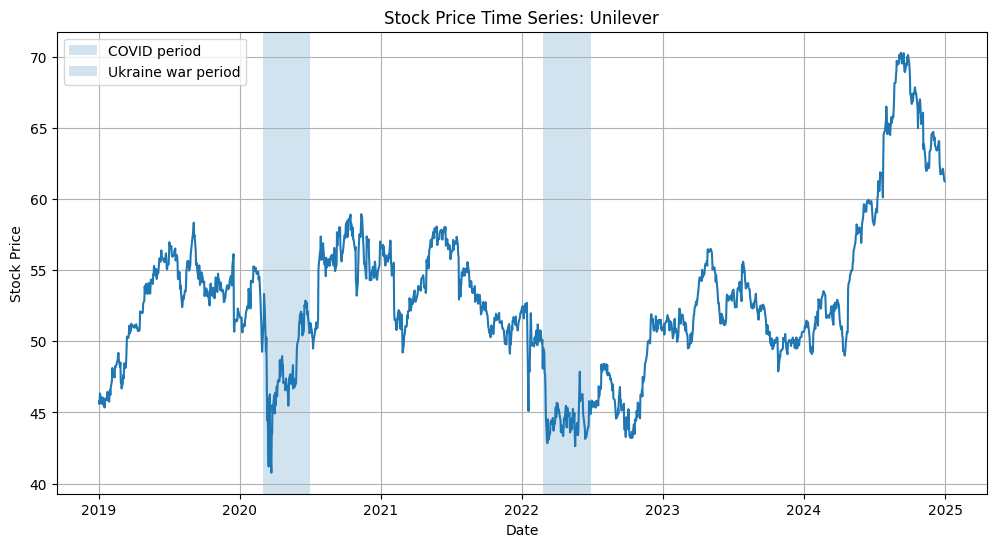

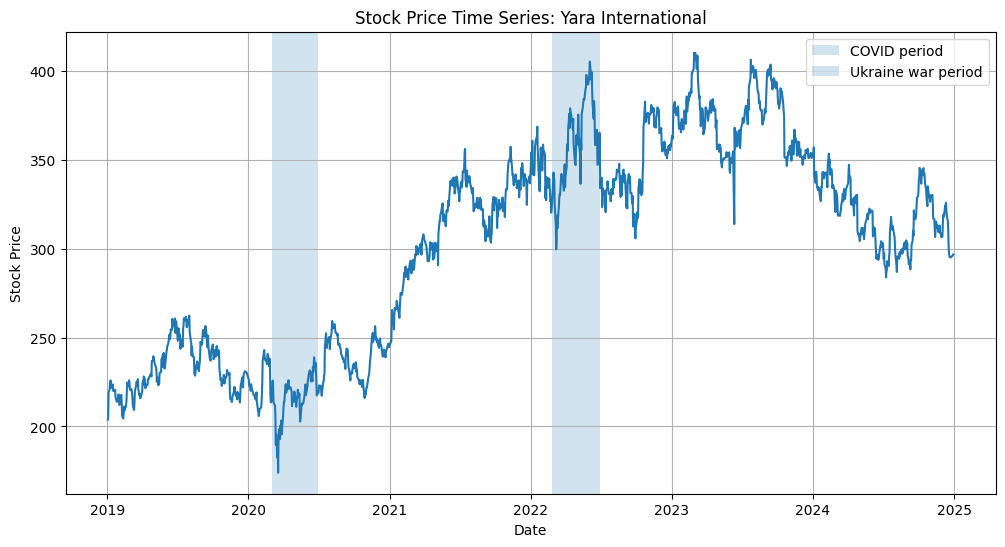

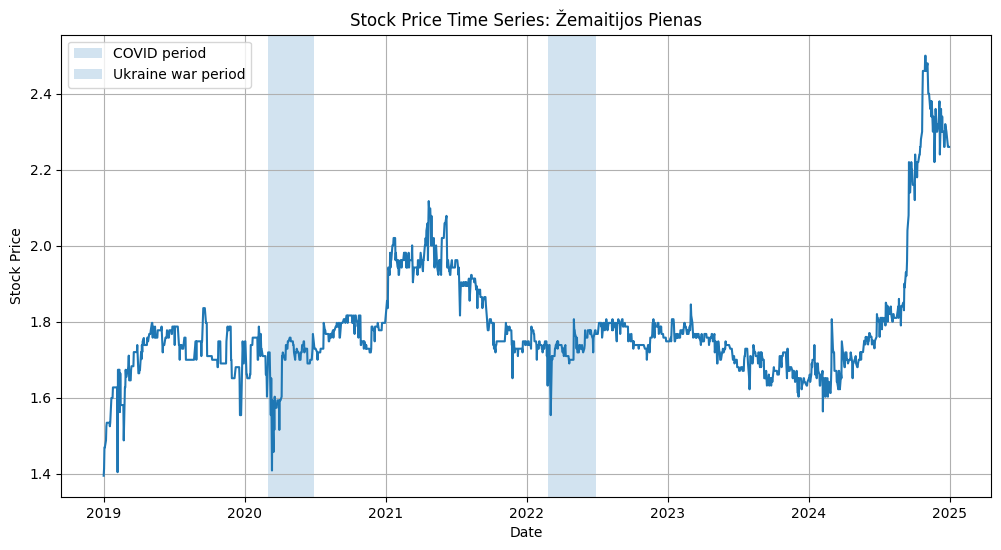

In [5]:
for company_name in df["Company"].unique():
    company_df = df[df["Company"] == company_name]

    plt.figure(figsize=(12, 6))
    plt.plot(company_df["Date"], company_df["Price"])

    plt.axvspan(pd.to_datetime("2020-03-01"), pd.to_datetime("2020-06-30"), alpha=0.2, label="COVID period")
    plt.axvspan(pd.to_datetime("2022-02-24"), pd.to_datetime("2022-06-30"), alpha=0.2, label="Ukraine war period")

    plt.title(f"Stock Price Time Series: {company_name}")
    plt.xlabel("Date")
    plt.ylabel("Stock Price")
    plt.legend()
    plt.grid(True)
    plt.show()

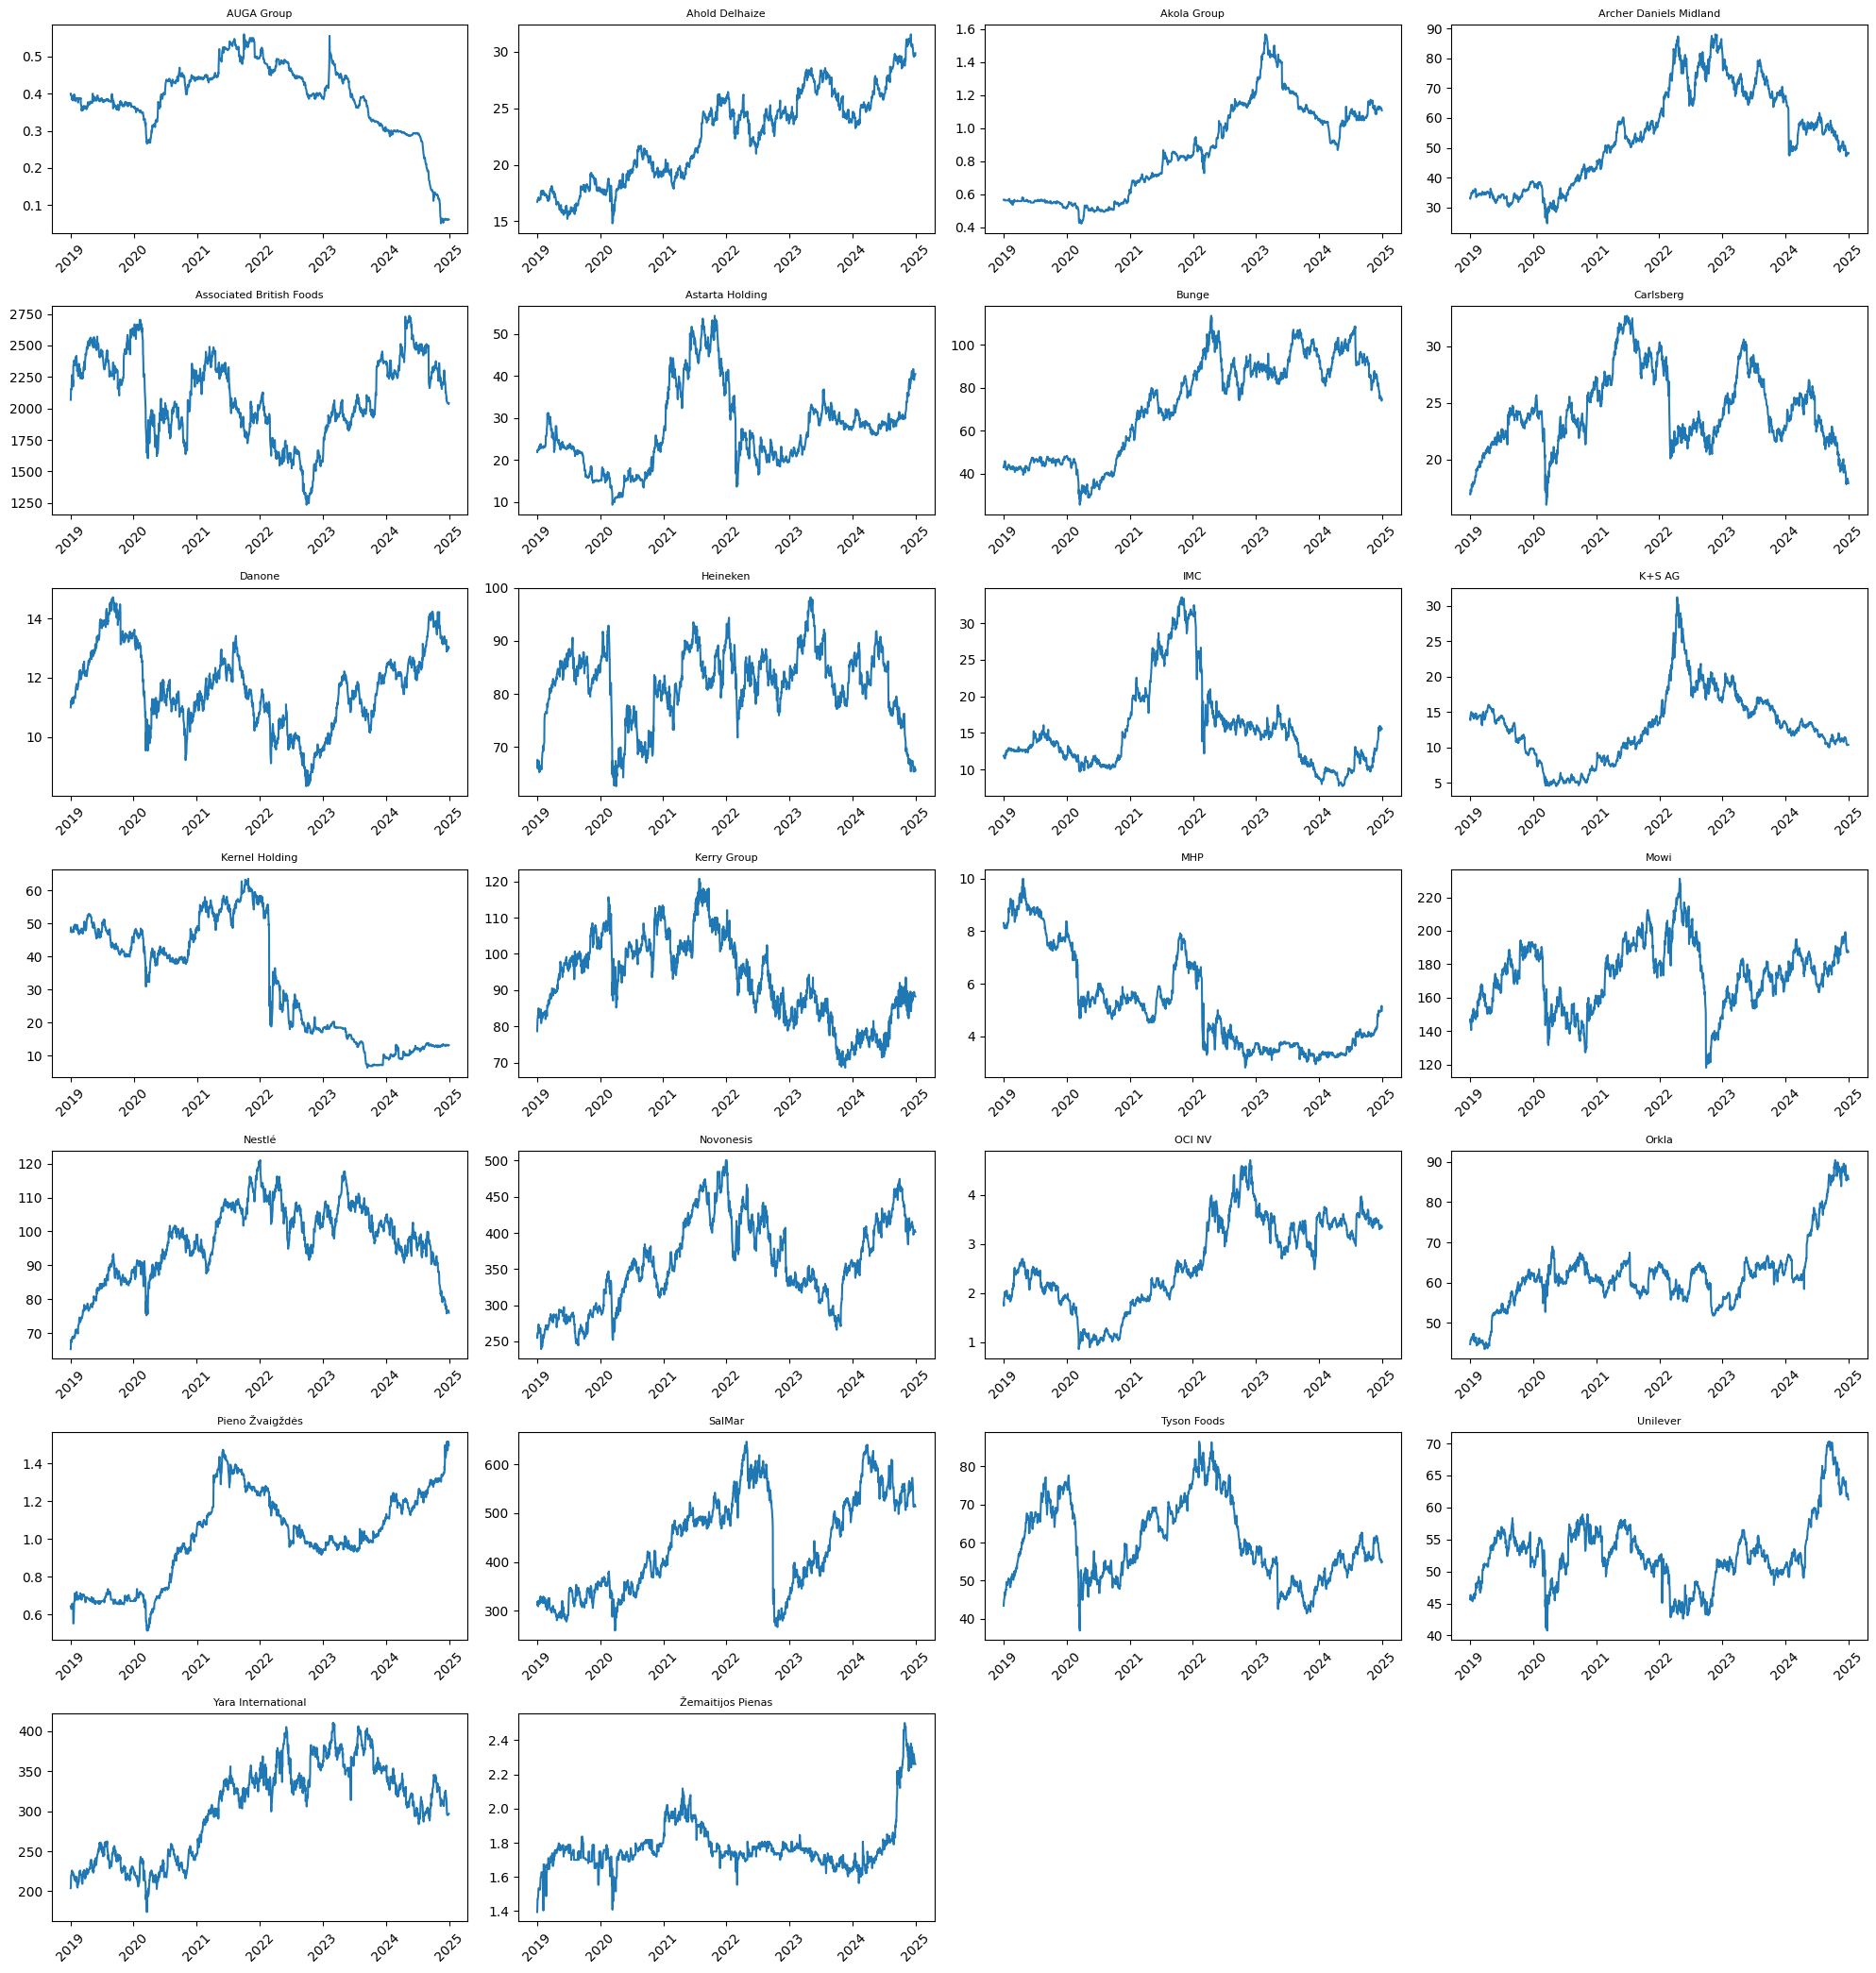

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("agrifood_stock_data_research_ready.csv")
df["Date"] = pd.to_datetime(df["Date"])

companies = df["Company"].unique()

n = len(companies)
cols = 4
rows = (n // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(20, rows*3))

axes = axes.flatten()

for i, company in enumerate(companies):
    data = df[df["Company"] == company]
    
    axes[i].plot(data["Date"], data["Price"])
    
    axes[i].set_title(company, fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [1]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
factors = [
    "F1","F2","F3","F4","F5",
    "F6","F7","F8","F9","F10",
    "F11","F12","F13","F14","F15"
]

n = len(factors)

In [4]:
fuzzy_scale = {
    "N": (0.00, 0.00, 0.25),
    "L": (0.00, 0.25, 0.50),
    "M": (0.25, 0.50, 0.75),
    "H": (0.50, 0.75, 1.00),
    "VH": (0.75, 1.00, 1.00)
}

In [5]:
file_path = "expert_responses.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15']



Normalized Matrix

[[0.    0.07  0.059 0.059 0.047 0.041 0.052 0.088 0.083 0.087 0.044 0.098
  0.092 0.047 0.055]
 [0.037 0.    0.055 0.058 0.063 0.075 0.065 0.064 0.078 0.081 0.096 0.063
  0.082 0.077 0.056]
 [0.051 0.025 0.    0.078 0.091 0.076 0.064 0.043 0.086 0.07  0.049 0.07
  0.046 0.086 0.058]
 [0.06  0.039 0.051 0.    0.053 0.091 0.097 0.097 0.104 0.085 0.1   0.053
  0.061 0.042 0.068]
 [0.039 0.03  0.062 0.044 0.    0.061 0.055 0.083 0.052 0.101 0.085 0.053
  0.044 0.08  0.083]
 [0.053 0.053 0.014 0.039 0.038 0.    0.076 0.051 0.045 0.057 0.054 0.077
  0.074 0.078 0.064]
 [0.019 0.051 0.054 0.051 0.076 0.054 0.    0.057 0.044 0.047 0.039 0.073
  0.057 0.058 0.09 ]
 [0.032 0.039 0.059 0.038 0.042 0.048 0.057 0.    0.094 0.082 0.092 0.088
  0.055 0.085 0.075]
 [0.063 0.066 0.034 0.031 0.05  0.055 0.094 0.087 0.    0.075 0.066 0.055
  0.051 0.053 0.097]
 [0.043 0.053 0.064 0.053 0.1   0.093 0.069 0.074 0.073 0.    0.052 0.084
  0.08  0.045 0.068]
 [0.052 0.013 0.008 0.036 0.076

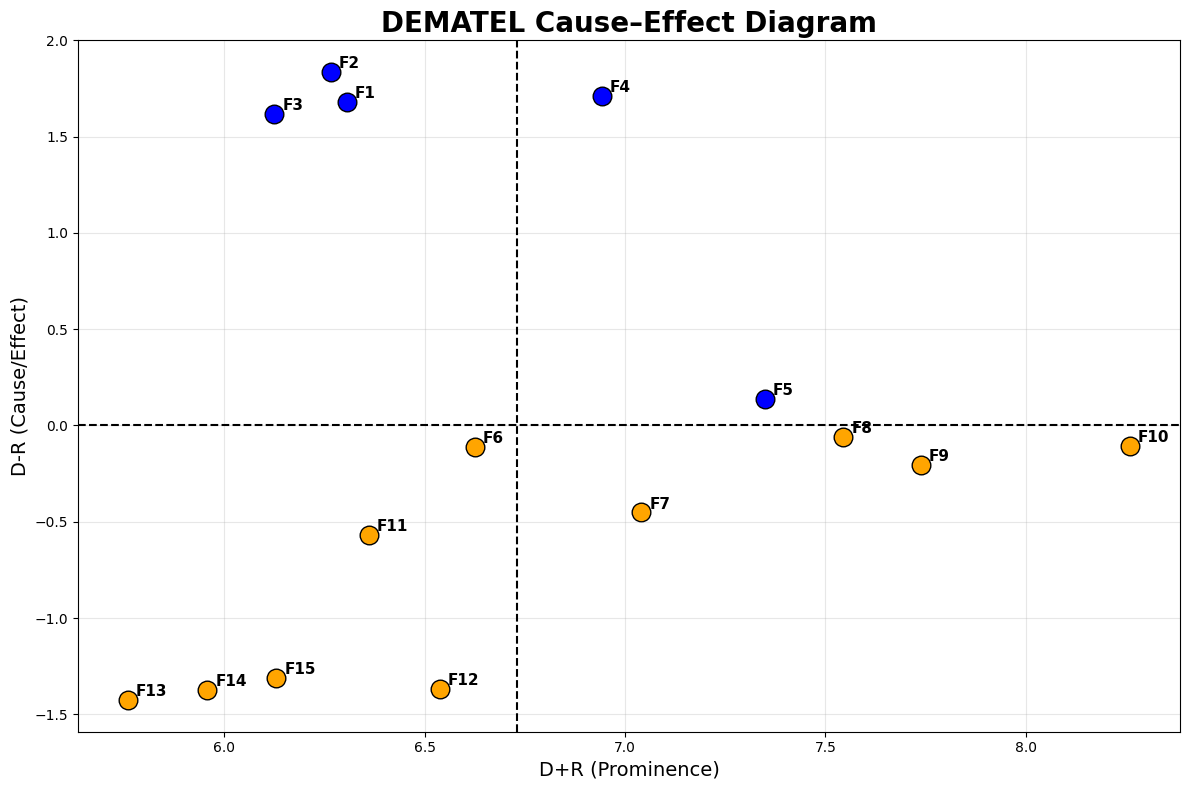


Analysis completed successfully.
Generated files:
1. DEMATEL_Output.xlsx
2. Cause_Effect_Diagram.png


In [49]:
# ==========================================================
# DEMATEL ANALYSIS
# FROM DIRECT RELATION MATRIX TO CAUSE-EFFECT DIAGRAM
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# STEP 1: READ DIRECT RELATION MATRIX
# ==========================================================

file_path = "direct_relation_matrix.xlsx"

# Read Excel
df = pd.read_excel(
    file_path,
    index_col=0
)

# Convert to numpy array
X = df.values

# Factor names
factors = df.columns.tolist()

# ==========================================================
# STEP 2: NORMALIZATION
# ==========================================================

# Row sums
row_sums = np.sum(X, axis=1)

# Column sums
col_sums = np.sum(X, axis=0)

# Maximum value
s = max(
    np.max(row_sums),
    np.max(col_sums)
)

# Normalized matrix
N = X / s

print("\n==============================")
print("Normalized Matrix")
print("==============================\n")

print(np.round(N,3))

# ==========================================================
# STEP 3: TOTAL RELATION MATRIX
# ==========================================================

I = np.identity(len(X))

T = np.dot(
    N,
    np.linalg.inv(I - N)
)

print("\n==============================")
print("Total Relation Matrix")
print("==============================\n")

print(np.round(T,3))

# ==========================================================
# STEP 4: CALCULATE D AND R
# ==========================================================

# D = row sums
D = np.sum(T, axis=1)

# R = column sums
R = np.sum(T, axis=0)

# Prominence and Relation
prominence = D + R

relation = D - R

# ==========================================================
# STEP 5: CREATE RESULTS TABLE
# ==========================================================

results = pd.DataFrame({

    'Factor' : factors,
    'D' : D,
    'R' : R,
    'D+R' : prominence,
    'D-R' : relation
})

print("\n==============================")
print("DEMATEL RESULTS")
print("==============================\n")

print(results.round(3))

# ==========================================================
# STEP 6: EXPORT RESULTS
# ==========================================================

with pd.ExcelWriter("DEMATEL_Output.xlsx") as writer:

    pd.DataFrame(
        N,
        index=factors,
        columns=factors
    ).to_excel(writer, sheet_name="Normalized_Matrix")

    pd.DataFrame(
        T,
        index=factors,
        columns=factors
    ).to_excel(writer, sheet_name="Total_Relation_Matrix")

    results.to_excel(writer, sheet_name="Results")

# ==========================================================
# STEP 7: CAUSE-EFFECT DIAGRAM
# ==========================================================

plt.figure(figsize=(12,8))

# Plot points
for i, factor in enumerate(factors):

    # Cause group
    if relation[i] > 0:
        color = 'blue'

    # Effect group
    else:
        color = 'orange'

    plt.scatter(
        prominence[i],
        relation[i],
        color=color,
        s=180,
        edgecolors='black'
    )

    # Labels
    plt.text(
        prominence[i] + 0.02,
        relation[i] + 0.02,
        factor,
        fontsize=11,
        weight='bold'
    )

# Average prominence line
avg_prominence = np.mean(prominence)

plt.axvline(
    x=avg_prominence,
    color='black',
    linestyle='--'
)

# Cause/effect line
plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

# Titles
plt.title(
    "DEMATEL Cause–Effect Diagram",
    fontsize=20,
    weight='bold'
)

plt.xlabel(
    "D+R (Prominence)",
    fontsize=14
)

plt.ylabel(
    "D-R (Cause/Effect)",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()

# Save graph
plt.savefig(
    "Cause_Effect_Diagram.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ==========================================================
# FINISHED
# ==========================================================

print("\nAnalysis completed successfully.")
print("Generated files:")
print("1. DEMATEL_Output.xlsx")
print("2. Cause_Effect_Diagram.png")

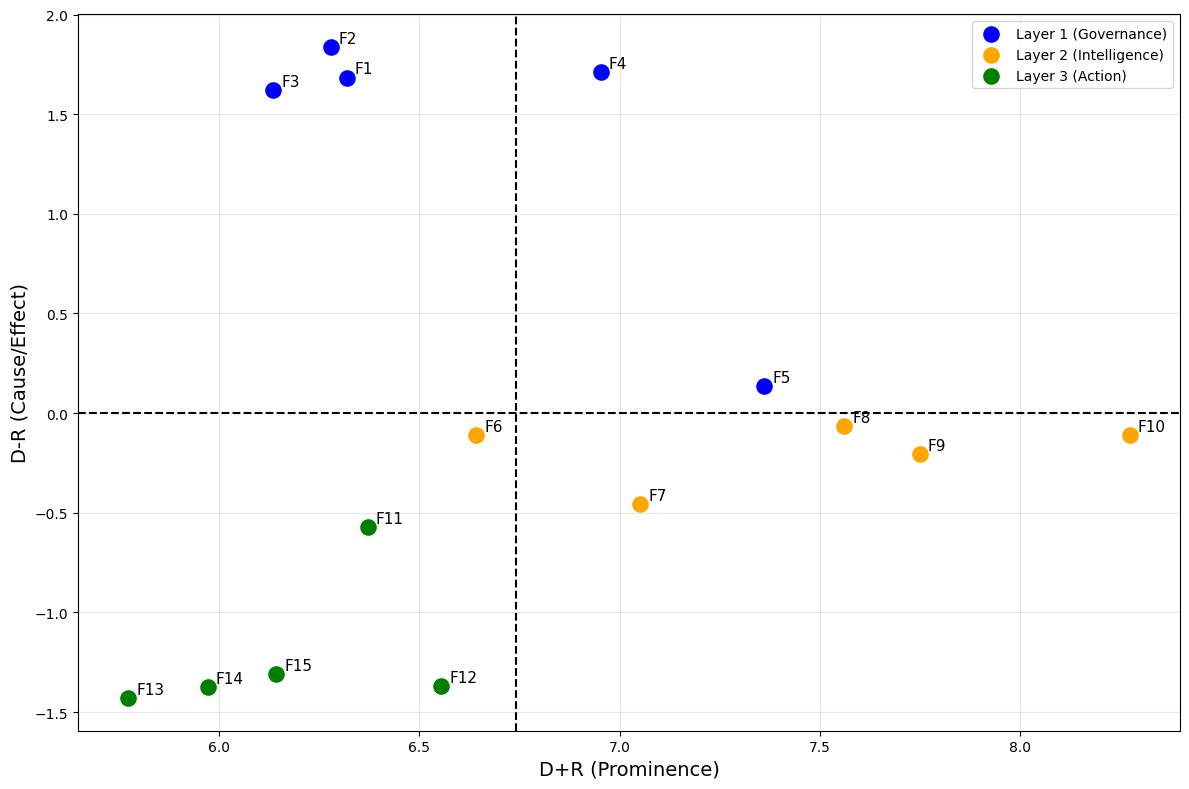

   Factor      D      R    D+R    D-R
0      F1  4.001  2.317  6.318  1.684
1      F2  4.058  2.220  6.278  1.838
2      F3  3.879  2.256  6.135  1.623
3      F4  4.333  2.620  6.953  1.713
4      F5  3.750  3.612  7.362  0.138
5      F6  3.265  3.377  6.642 -0.112
6      F7  3.299  3.753  7.052 -0.454
7      F8  3.749  3.812  7.561 -0.063
8      F9  3.773  3.977  7.750 -0.204
9     F10  4.083  4.192  8.275 -0.109
10    F11  2.901  3.470  6.371 -0.569
11    F12  2.592  3.962  6.554 -1.370
12    F13  2.171  3.601  5.772 -1.430
13    F14  2.298  3.673  5.971 -1.375
14    F15  2.416  3.726  6.142 -1.310


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# READ TOTAL RELATION MATRIX
# ==========================

# Excel file path
file_path = "DEMATEL_matrices.xlsx"

# Read Total Relation Matrix sheet
T = pd.read_excel(
    file_path,
    sheet_name="Total_Relation_Matrix",
    index_col=0
)

# Convert to numpy array
T = T.values

# Factor names
factors = [f"F{i}" for i in range(1, 16)]

# ==========================
# CALCULATE D AND R
# ==========================

# D = row sums
D = np.sum(T, axis=1)

# R = column sums
R = np.sum(T, axis=0)

# Prominence and Relation
prominence = D + R
relation = D - R

# ==========================
# DEFINE LAYERS
# ==========================

layer1 = ['F1', 'F2', 'F3', 'F4', 'F5']
layer2 = ['F6', 'F7', 'F8', 'F9', 'F10']
layer3 = ['F11', 'F12', 'F13', 'F14', 'F15']

# ==========================
# CREATE PLOT
# ==========================

plt.figure(figsize=(12,8))

for i, factor in enumerate(factors):

    # Select color by layer
    if factor in layer1:
        color = 'blue'
        label = 'Layer 1 (Governance)'
    elif factor in layer2:
        color = 'orange'
        label = 'Layer 2 (Intelligence)'
    else:
        color = 'green'
        label = 'Layer 3 (Action)'

    # Avoid duplicate legend labels
    if factor != layer1[0] and factor != layer2[0] and factor != layer3[0]:
        label = None

    # Scatter point
    plt.scatter(
        prominence[i],
        relation[i],
        color=color,
        s=120,
        label=label
    )

    # Factor label
    plt.text(
        prominence[i] + 0.02,
        relation[i] + 0.02,
        factor,
        fontsize=11
    )

# ==========================
# AVERAGE LINES
# ==========================

avg_prominence = np.mean(prominence)

plt.axvline(
    x=avg_prominence,
    color='black',
    linestyle='--'
)

plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

# ==========================
# GRAPH SETTINGS
# ==========================

# plt.title(
#     "Fuzzy DEMATEL Cause–Effect Diagram",
#     fontsize=18,
#     weight='bold'
# )

plt.xlabel(
    "D+R (Prominence)",
    fontsize=14
)

plt.ylabel(
    "D-R (Cause/Effect)",
    fontsize=14
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# ==========================
# SAVE GRAPH
# ==========================

plt.savefig(
    "Cause_Effect_Diagram.jpg",
    dpi=300
)

plt.show()

# ==========================
# PRINT VALUES
# ==========================

results = pd.DataFrame({
    'Factor': factors,
    'D': D,
    'R': R,
    'D+R': prominence,
    'D-R': relation
})

print(results.round(3))

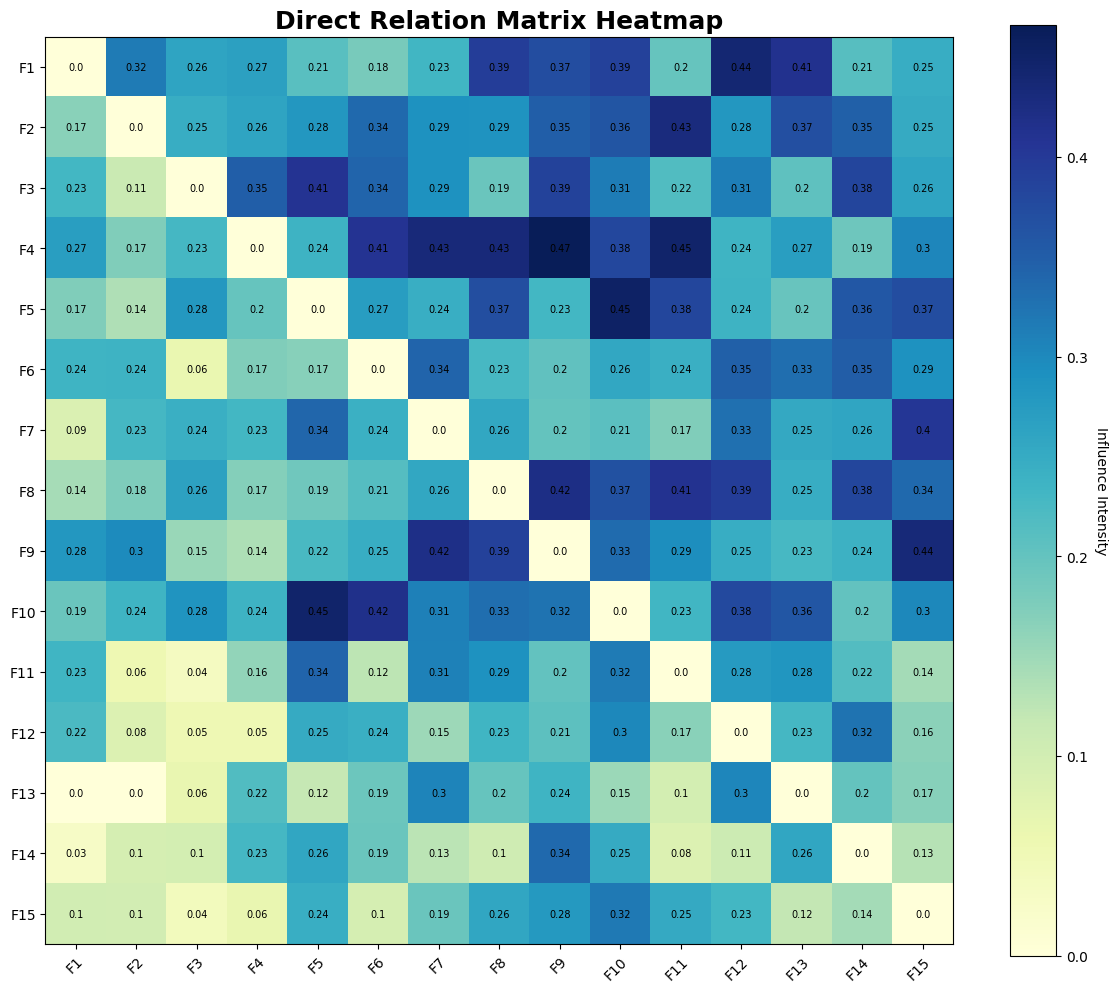

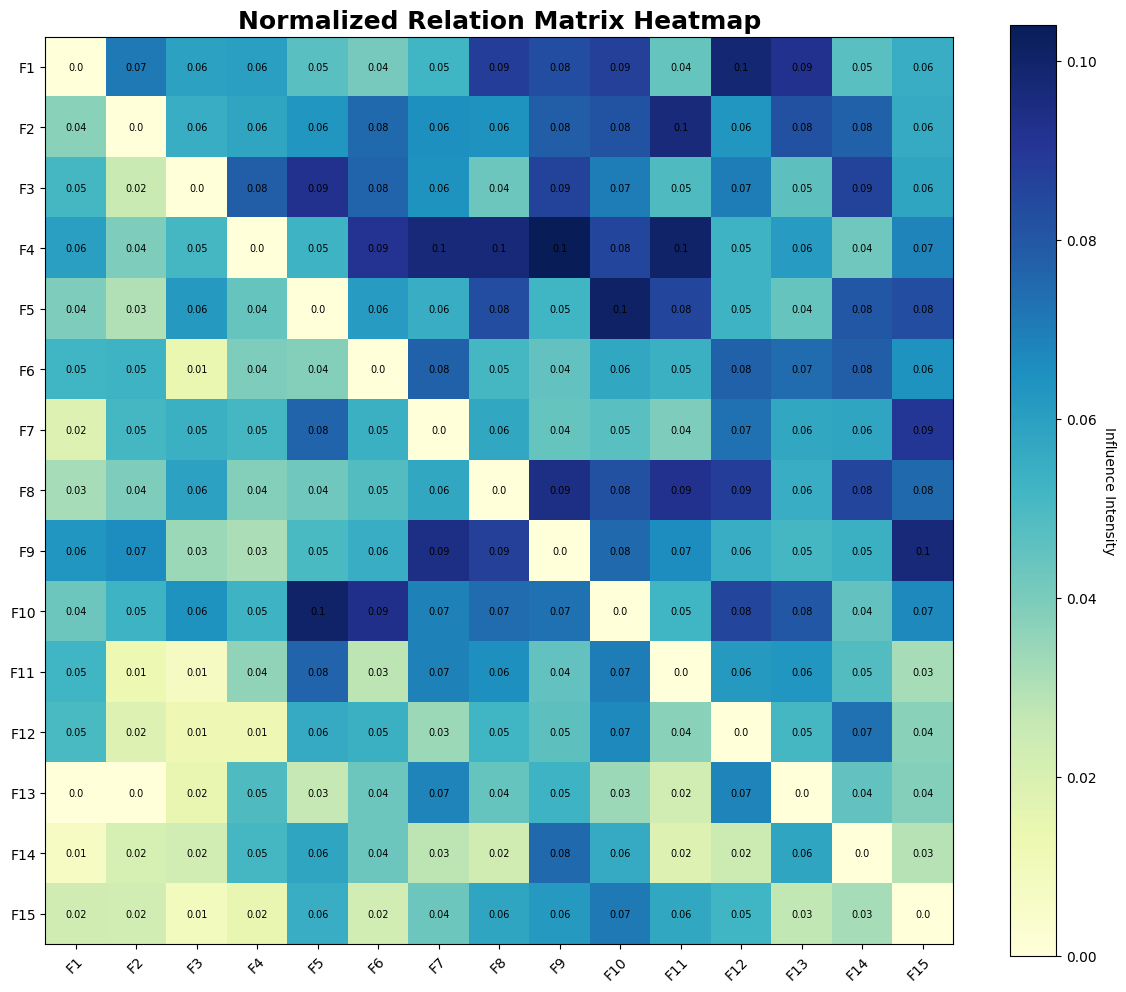

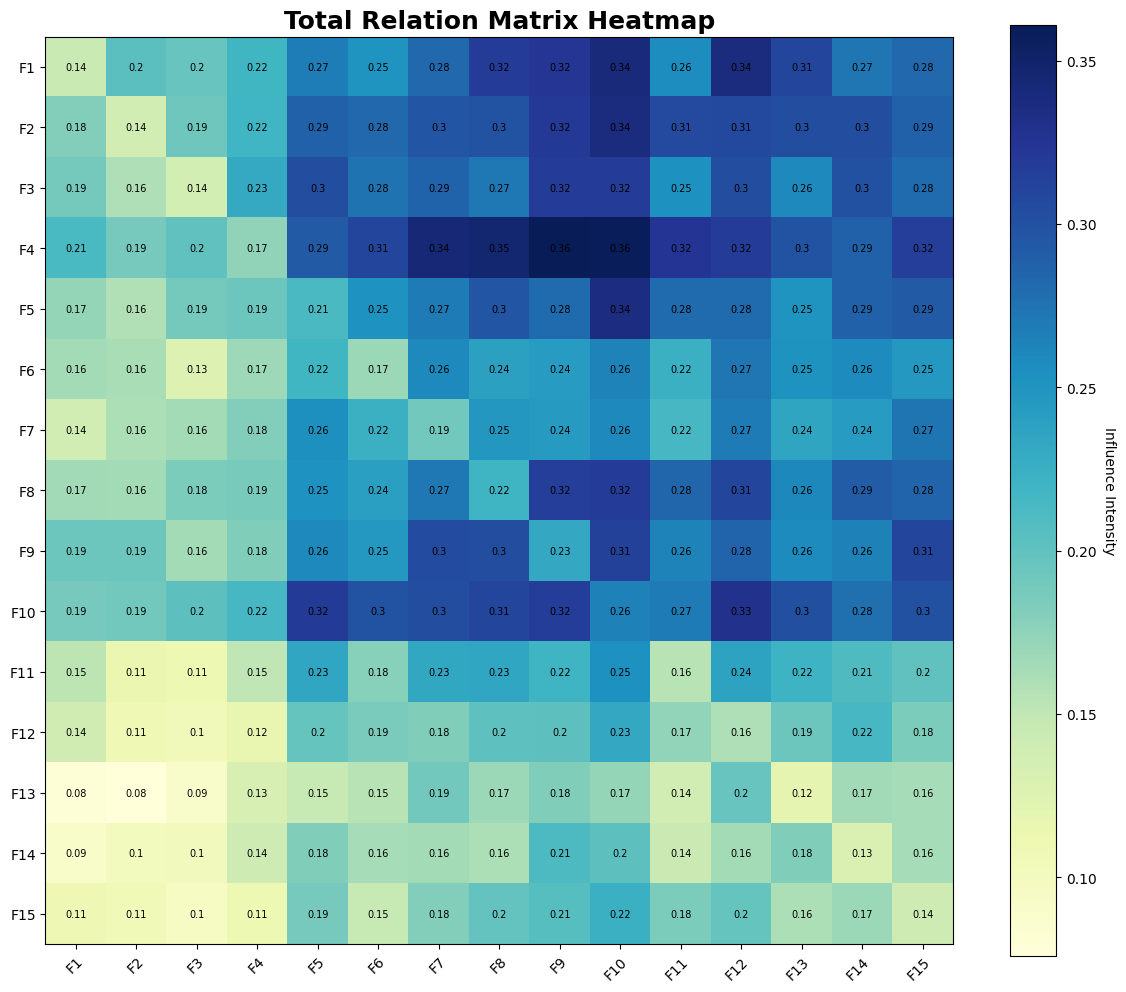

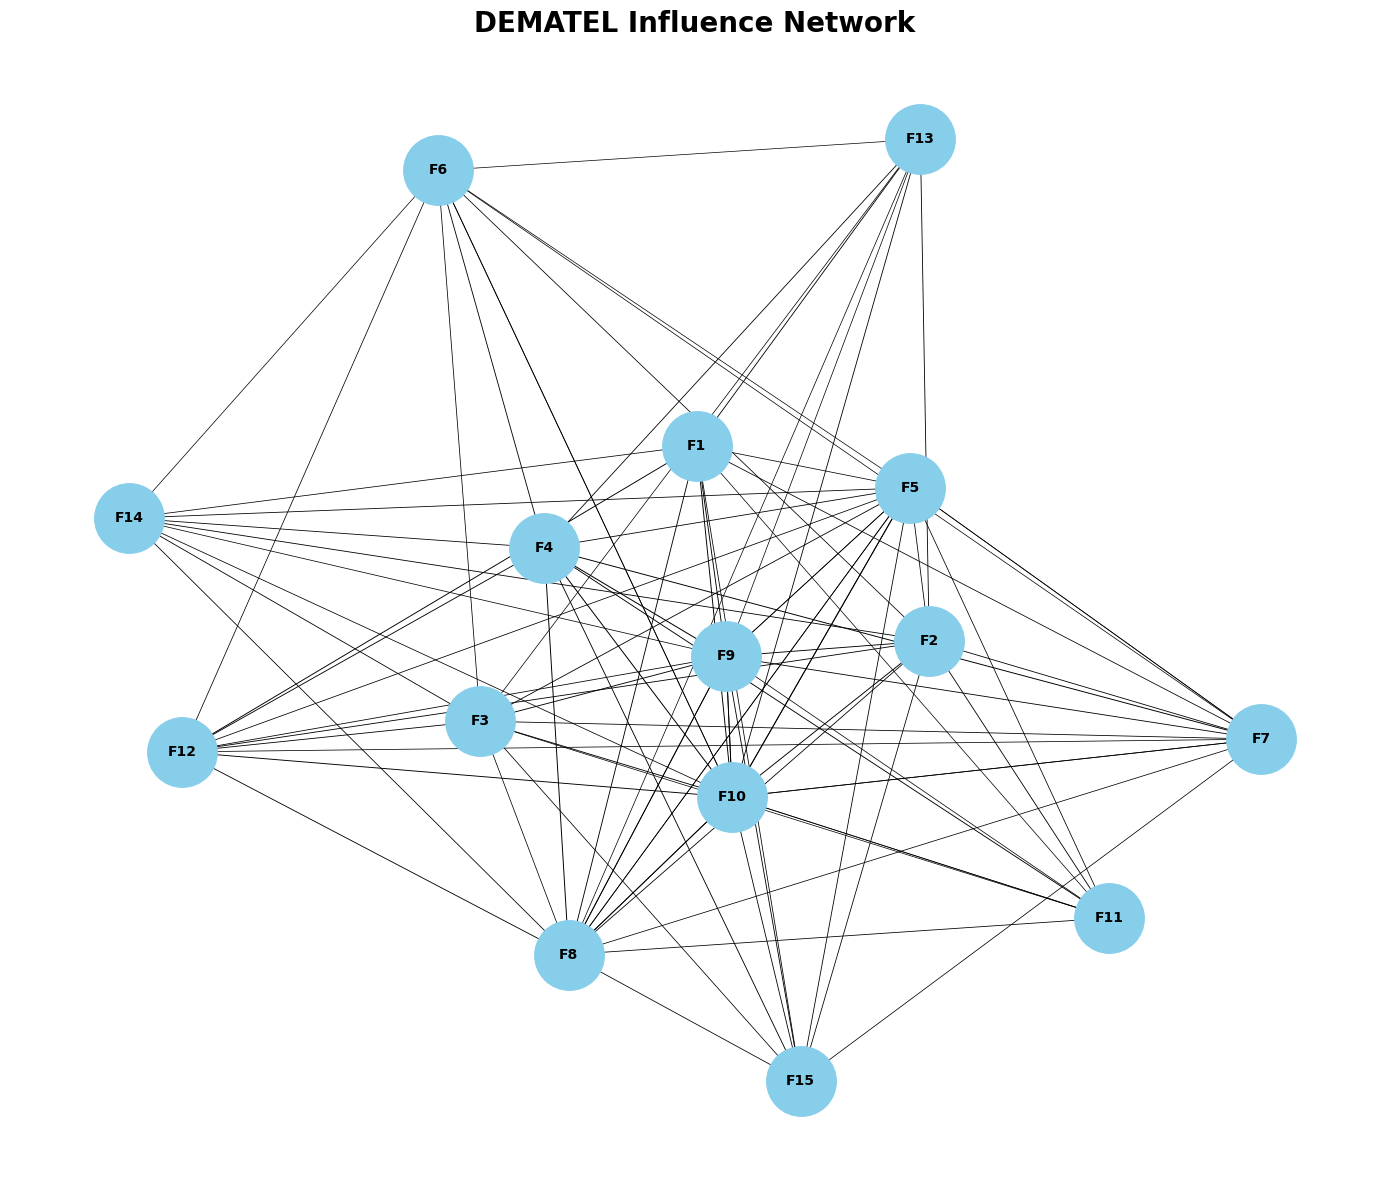

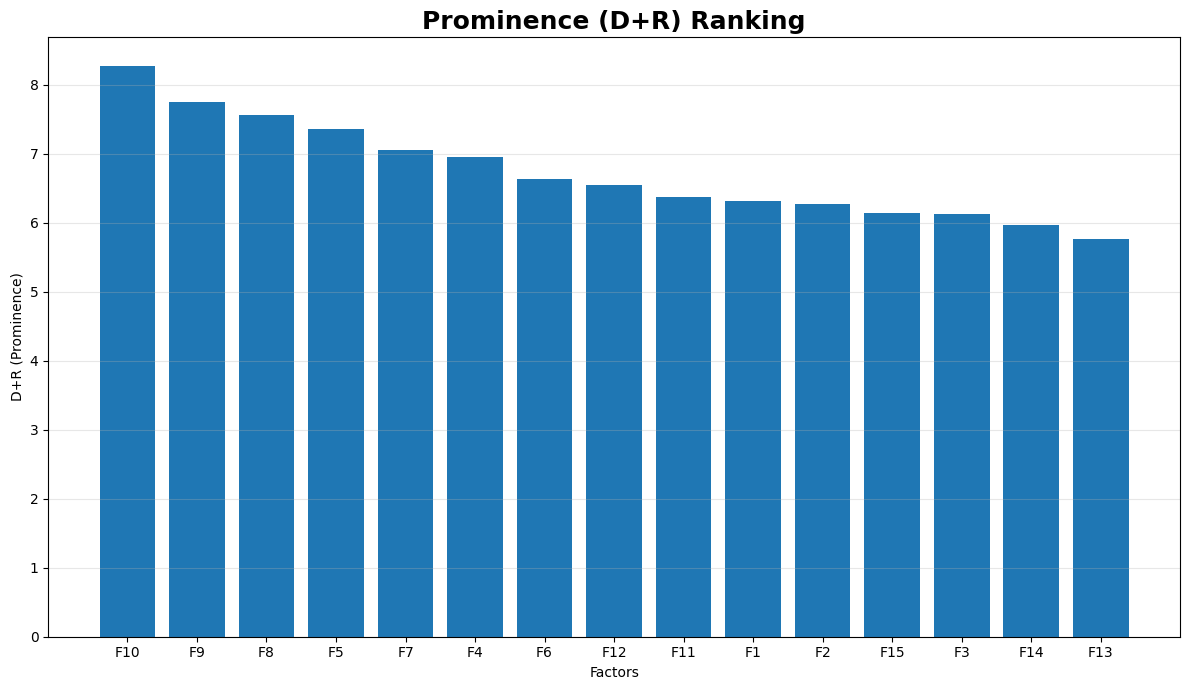

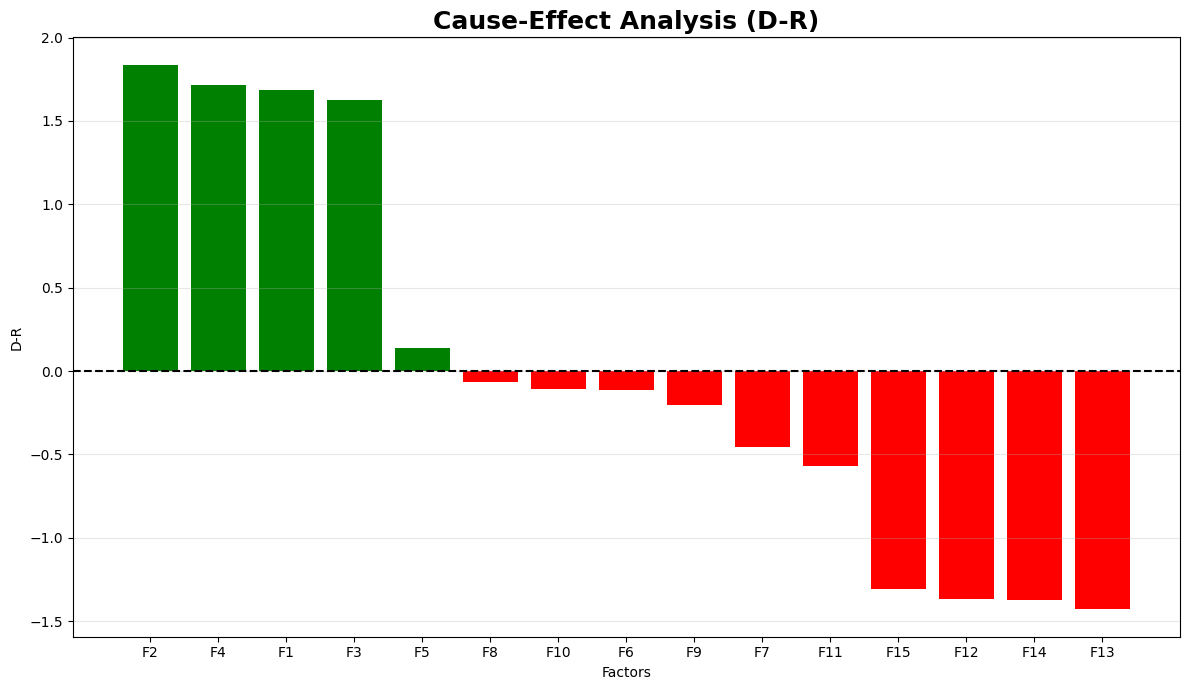


DEMATEL Results:

   Factor  Prominence  Relation
1      F2       6.278     1.838
3      F4       6.953     1.713
0      F1       6.318     1.684
2      F3       6.135     1.623
4      F5       7.362     0.138
7      F8       7.561    -0.063
9     F10       8.275    -0.109
5      F6       6.642    -0.112
8      F9       7.750    -0.204
6      F7       7.052    -0.454
10    F11       6.371    -0.569
14    F15       6.142    -1.310
11    F12       6.554    -1.370
13    F14       5.971    -1.375
12    F13       5.772    -1.430


In [51]:
# =========================================================
# ADVANCED DEMATEL VISUALIZATION CODE
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD EXCEL FILE
# =========================================================

file_path = "DEMATEL_Matrices.xlsx"

direct = pd.read_excel(
    file_path,
    sheet_name="Direct_Relation_Matrix",
    index_col=0
)

normalized = pd.read_excel(
    file_path,
    sheet_name="Normalized_Matrix",
    index_col=0
)

total = pd.read_excel(
    file_path,
    sheet_name="Total_Relation_Matrix",
    index_col=0
)

# =========================================================
# HEATMAP FUNCTION
# =========================================================

def plot_heatmap(matrix, title):

    fig, ax = plt.subplots(figsize=(12,10))

    heatmap = ax.imshow(
        matrix,
        cmap='YlGnBu'
    )

    # Axis labels
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))

    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)

    # Rotate labels
    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

    # Add values inside cells
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            text = ax.text(
                j,
                i,
                round(matrix.iloc[i, j], 2),
                ha="center",
                va="center",
                color="black",
                fontsize=7
            )

    # Color bar
    cbar = plt.colorbar(heatmap)
    cbar.ax.set_ylabel(
        "Influence Intensity",
        rotation=-90,
        va="bottom"
    )

    plt.title(
        title,
        fontsize=18,
        weight='bold'
    )

    plt.tight_layout()
    plt.show()

# =========================================================
# PLOT HEATMAPS
# =========================================================

plot_heatmap(
    direct,
    "Direct Relation Matrix Heatmap"
)

plot_heatmap(
    normalized,
    "Normalized Relation Matrix Heatmap"
)

plot_heatmap(
    total,
    "Total Relation Matrix Heatmap"
)

# =========================================================
# NETWORK VISUALIZATION
# =========================================================

import networkx as nx

# Threshold for showing links
threshold = 0.25

G = nx.DiGraph()

factors = total.columns.tolist()

# Add nodes
for factor in factors:
    G.add_node(factor)

# Add edges
for i in range(len(factors)):
    for j in range(len(factors)):

        value = total.iloc[i, j]

        if i != j and value > threshold:

            G.add_edge(
                factors[i],
                factors[j],
                weight=value
            )

# Plot network
plt.figure(figsize=(14,12))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500,
    node_color='skyblue'
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

# Draw edges
weights = [
    G[u][v]['weight'] * 2
    for u,v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    arrows=True,
    arrowstyle='->',
    arrowsize=20
)

plt.title(
    "DEMATEL Influence Network",
    fontsize=20,
    weight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()

# =========================================================
# PROMINENCE BAR CHART
# =========================================================

T = total.values

D = np.sum(T, axis=1)
R = np.sum(T, axis=0)

prominence = D + R
relation = D - R

results = pd.DataFrame({
    'Factor': factors,
    'Prominence': prominence,
    'Relation': relation
})

# Sort by prominence
results = results.sort_values(
    by='Prominence',
    ascending=False
)

# Plot
plt.figure(figsize=(12,7))

plt.bar(
    results['Factor'],
    results['Prominence']
)

plt.title(
    "Prominence (D+R) Ranking",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Factors")
plt.ylabel("D+R (Prominence)")

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# =========================================================
# CAUSE-EFFECT BAR CHART
# =========================================================

results = results.sort_values(
    by='Relation',
    ascending=False
)

plt.figure(figsize=(12,7))

colors = [
    'green' if x > 0 else 'red'
    for x in results['Relation']
]

plt.bar(
    results['Factor'],
    results['Relation'],
    color=colors
)

plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

plt.title(
    "Cause-Effect Analysis (D-R)",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Factors")
plt.ylabel("D-R")

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# =========================================================
# PRINT FINAL RESULTS
# =========================================================

print("\nDEMATEL Results:\n")
print(results.round(3))

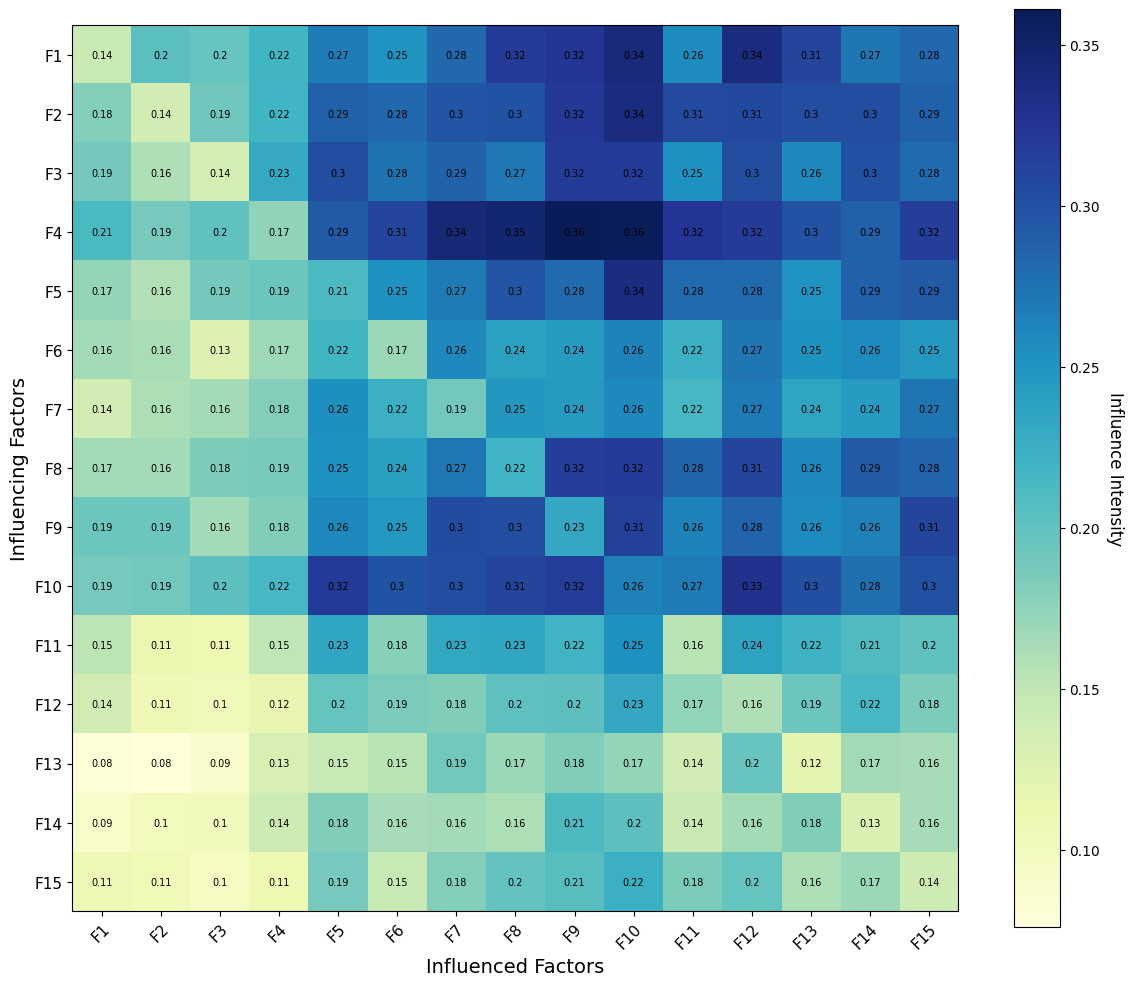

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD TOTAL RELATION MATRIX
# =====================================================

file_path = "DEMATEL_Matrices.xlsx"

total = pd.read_excel(
    file_path,
    sheet_name="Total_Relation_Matrix",
    index_col=0
)

# =====================================================
# CREATE HEATMAP
# =====================================================

fig, ax = plt.subplots(figsize=(12,10))

heatmap = ax.imshow(
    total,
    cmap='YlGnBu'   # Bluish color theme
)

# =====================================================
# AXIS LABELS
# =====================================================

ax.set_xticks(np.arange(len(total.columns)))
ax.set_yticks(np.arange(len(total.index)))

ax.set_xticklabels(total.columns, fontsize=11)
ax.set_yticklabels(total.index, fontsize=11)

# Rotate x labels
plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

# =====================================================
# ADD VALUES INSIDE CELLS
# =====================================================

for i in range(len(total.index)):
    for j in range(len(total.columns)):

        value = round(total.iloc[i, j], 2)

        ax.text(
            j,
            i,
            value,
            ha="center",
            va="center",
            color="black",
            fontsize=7
        )

# =====================================================
# COLOR BAR
# =====================================================

cbar = plt.colorbar(heatmap)

cbar.ax.set_ylabel(
    "Influence Intensity",
    rotation=-90,
    va="bottom",
    fontsize=12
)


# =====================================================
# TITLES
# =====================================================

# plt.title(
#     "Total Relation Matrix Heatmap",
#     fontsize=20,
#     weight='bold'
# )

plt.xlabel(
    "Influenced Factors",
    fontsize=14
)

plt.ylabel(
    "Influencing Factors",
    fontsize=14
)

# =====================================================
# SAVE FIGURE
# =====================================================

plt.tight_layout()

plt.savefig(
    "Total_Relation_Heatmap.jpg",
    dpi=600,
    bbox_inches='tight'
)

plt.show()